In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data["caffeine_class"]

column_names = X.columns

Binary classification - Model choice

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

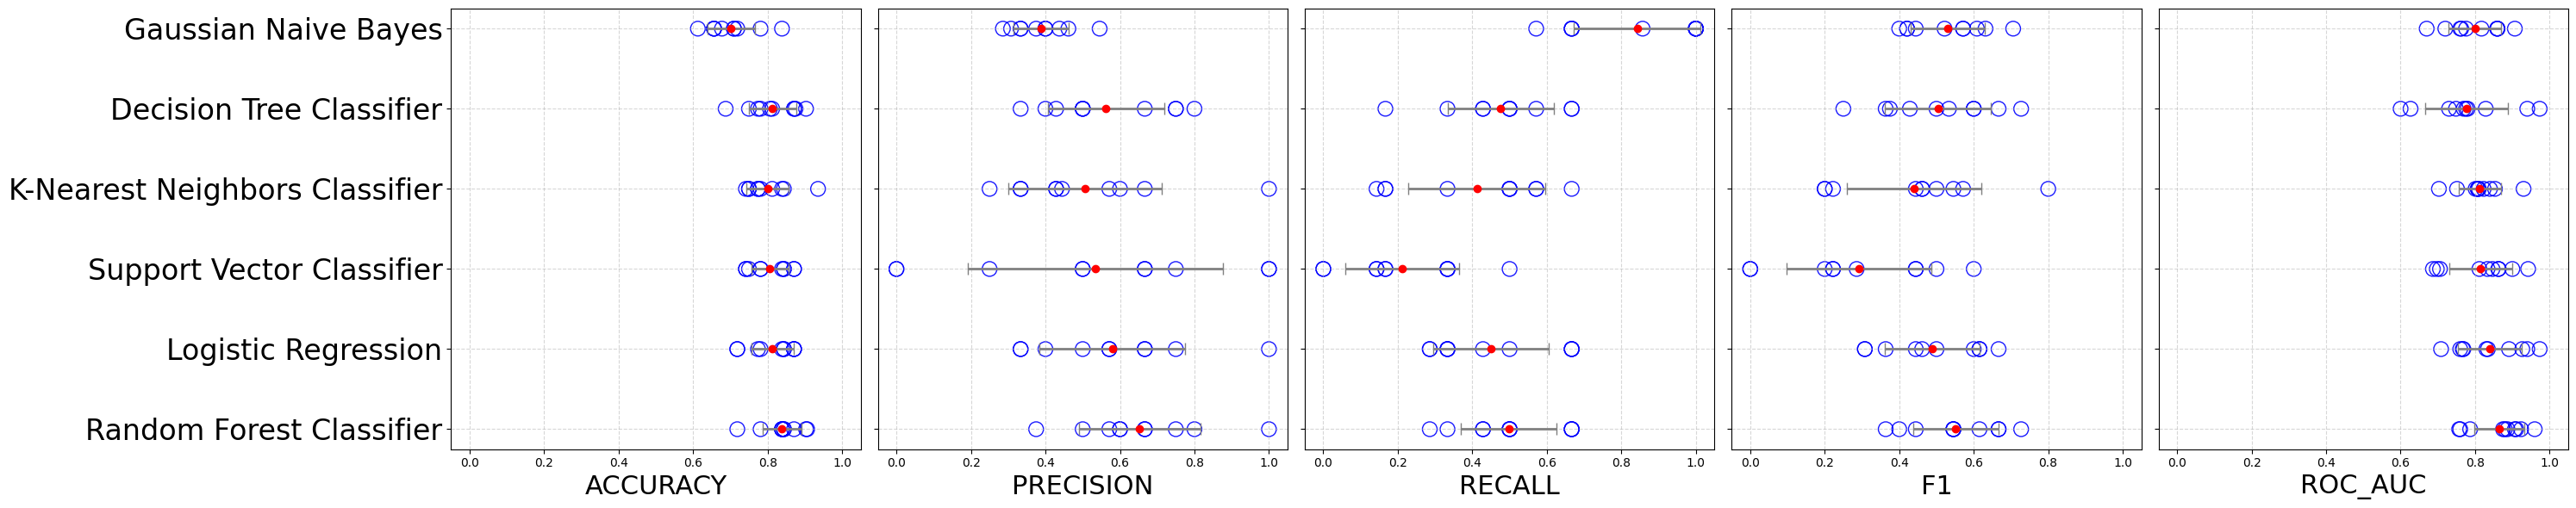

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# ── DEFINE MODELS ────────────────────────────────────────────────────────
models = [
    ("Random Forest Classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
    (
        "Logistic Regression",
        Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000, random_state=42)),
            ]
        ),
    ),
    (
        "Support Vector Classifier",
        Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", SVC(probability=True, random_state=42)),
            ]
        ),
    ),
    (
        "K-Nearest Neighbors Classifier",
        Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier()),
            ]
        ),
    ),
    ("Decision Tree Classifier", DecisionTreeClassifier(random_state=42)),
    ("Gaussian Naive Bayes", GaussianNB()),
]

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_folds = 10

# ── CROSS-VALIDATION ──────────────────────────────────────────────────────
results = {m: [] for m in scoring_metrics}
all_scores = {m: [] for m in scoring_metrics}

for name, model in models:
    for metric in scoring_metrics:
        # skip roc_auc if the model has no probability or decision_function
        if metric == "roc_auc" and not (
            hasattr(model, "predict_proba") or hasattr(model, "decision_function")
        ):
            continue

        scores = cross_val_score(
            model, X_train, y_train, cv=cv_folds, scoring=metric
        )
        results[metric].append(
            {
                "Model": name,
                "Mean Score": scores.mean(),
                "Std Dev": scores.std(),
            }
        )
        all_scores[metric] += [
            {"Model": name, "Score": s, "Metric": metric} for s in scores
        ]

# Convert into DataFrames for easy plotting
results_df = {
    metric: pd.DataFrame(results[metric]) for metric in scoring_metrics
}
all_scores_df = pd.DataFrame(
    [entry for metric_list in all_scores.values() for entry in metric_list]
)

# ── VISUALIZE ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(30, 6), sharey=True)

# collect all scores to set a common x‐axis limit
global_scores = all_scores_df["Score"]
x_min, x_max = global_scores.min() - 0.05, global_scores.max() + 0.05

for ax, metric in zip(axes, scoring_metrics):
    df_res = results_df[metric]
    # scatter each model's CV folds at the same y-position
    for i, row in df_res.iterrows():
        model_name = row["Model"]
        scores = all_scores_df.query(
            "Model == @model_name and Metric == @metric"
        )["Score"].values

        # all points at y=i
        y_positions = np.full_like(scores, fill_value=i, dtype=float)

        ax.scatter(
            scores,
            y_positions,
            edgecolor="blue",
            facecolors="none",
            alpha=0.9,
            s=150,
        )

    # plot mean ± std  
    ax.errorbar(
        df_res["Mean Score"],
        range(len(df_res)),
        xerr=df_res["Std Dev"],
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=5,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(range(len(df_res)))
    ax.set_yticklabels(df_res["Model"], fontsize=24)
    ax.set_xlabel(metric.upper(), fontsize=22)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


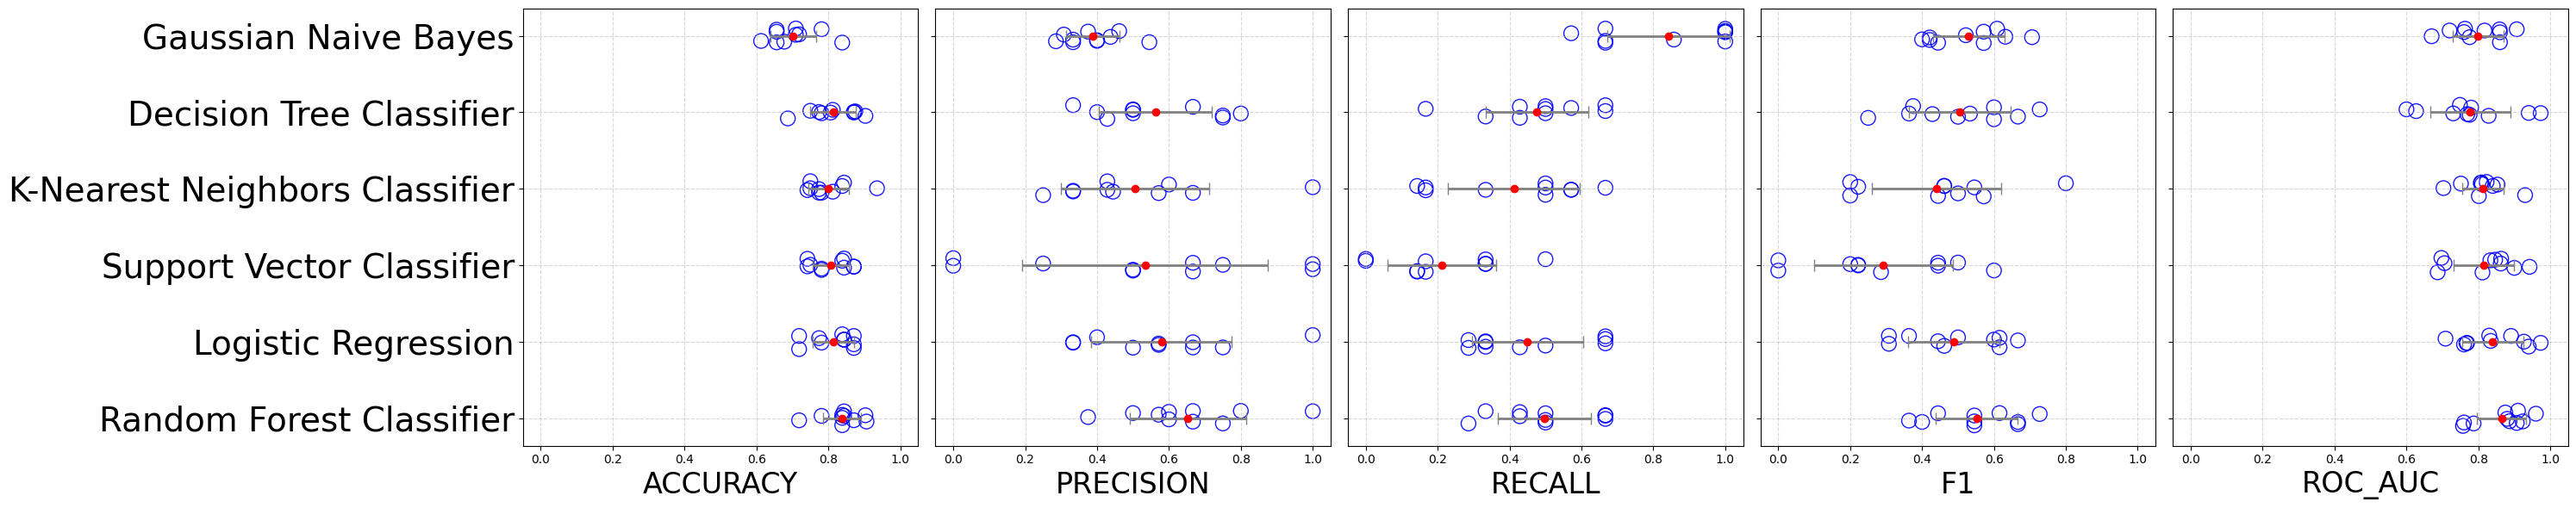

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


models = [
    ("Random Forest Classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
    (
        "Logistic Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]),
    ),
    (
        "Support Vector Classifier",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42)),
        ]),
    ),
    (
        "K-Nearest Neighbors Classifier",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
    ),
    ("Decision Tree Classifier", DecisionTreeClassifier(random_state=42)),
    ("Gaussian Naive Bayes", GaussianNB()),
]

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_folds = 10

xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²"
}

# ── 4) CROSS-VALIDATION ──────────────────────────────────────────────────────
results = {m: [] for m in scoring_metrics}
all_scores = {m: [] for m in scoring_metrics}

for name, model in models:
    for metric in scoring_metrics:
        # Skip roc_auc if model has no probability or decision_function
        if metric == "roc_auc" and not (
            hasattr(model, "predict_proba") or hasattr(model, "decision_function")
        ):
            continue

        scores = cross_val_score(
            model, X_train, y_train, cv=cv_folds, scoring=metric
        )
        results[metric].append({
            "Model": name,
            "Mean Score": scores.mean(),
            "Std Dev":   scores.std()
        })
        all_scores[metric] += [
            {"Model": name, "Score": s, "Metric": metric}
            for s in scores
        ]

# Convert into DataFrames
results_df    = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame(
    [entry for metric_list in all_scores.values() for entry in metric_list]
)

# ── 5) VISUALIZE WITH VERTICAL JITTER ────────────────────────────────────────
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(30, 6), sharey=True)

# Determine a common x-axis limit
global_scores = all_scores_df["Score"]
x_min, x_max = global_scores.min() - 0.05, global_scores.max() + 0.05

for ax, metric in zip(axes, scoring_metrics):
    df_res = results_df[metric]
    
    # Scatter each CV fold with a small jitter around the model's y-index
    for i, row in df_res.iterrows():
        model_name = row["Model"]
        scores     = all_scores_df.query(
            "Model == @model_name and Metric == @metric"
        )["Score"].values
        
        # Add vertical jitter in [-0.1, +0.1]
        y_jitter = i + np.random.uniform(-0.1, 0.1, size=scores.shape)
        
        ax.scatter(
            scores,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.9,
            s=150,
        )

    # Plot mean ± std exactly at y=i
    ax.errorbar(
        df_res["Mean Score"],
        range(len(df_res)),
        xerr=df_res["Std Dev"],
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=5,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(range(len(df_res)))
    ax.set_yticklabels(df_res["Model"], fontsize=28)
    ax.set_xlabel(metric.upper(), fontsize=24)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Regression Analysis - Model choice

In [6]:
# Filter for caffeinated samples
df_reg = coffee_data[coffee_data["caffeine_class"] == 1].copy()
#print(df_reg.describe())
df_no_outliers = df_reg[df_reg['caffeine_percent'] != 0.7]
print(df_no_outliers.describe())



       clim_68_pet_annual  clim_21_tmax9_sep  clim_55_prec_coldest_q  clim_49_prec_wettest_m  clim_48_Annual_prec  clim_60_pet5_may  clim_43_tannual_range  clim_34_prec10_oct  clim_35_prec11_nov  clim_39_isotherm  ...  env_78_wat_22  env_78_wat_17  env_78_wat_1.1  env_78_wat_18  env_78_wat_15  env_78_wat_19  env_78_wat_24  env_78_wat_0  caffeine_class  caffeine_percent
count           87.000000          87.000000               87.000000               87.000000            87.000000         87.000000              87.000000           87.000000           87.000000         87.000000  ...      87.000000           87.0            87.0           87.0           87.0           87.0           87.0     87.000000            87.0         87.000000
mean          1158.793103         257.563218              292.459770              371.356322          2152.793103         85.114943             149.275862          134.701149          239.413793         62.931034  ...       0.022989            0.0         

Removing all 0 columns after selecting subset of class 1(ie rows with caffeine content)

In [7]:

# 2. Identify columns that are all zero
zero_cols = [col for col in df_no_outliers.columns if df_no_outliers[col].eq(0).all()]

# 3. Drop them
df_no_outliers.drop(columns=zero_cols, inplace=True)
df_no_outliers.describe()

C:\Users\forc2101\AppData\Local\Temp\ipykernel_18236\3687516312.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers.drop(columns=zero_cols, inplace=True)


,clim_68_pet_annual,clim_21_tmax9_sep,clim_55_prec_coldest_q,clim_49_prec_wettest_m,clim_48_Annual_prec,clim_60_pet5_may,clim_43_tannual_range,clim_34_prec10_oct,clim_35_prec11_nov,clim_39_isotherm,...,env_78_wat_8,env_78_wat_2,env_78_wat_4,env_78_wat_20,env_78_wat_3,env_78_wat_14,env_78_wat_22,env_78_wat_0,caffeine_class,caffeine_percent
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,...,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.0,87.000000
mean,1158.793103,257.563218,292.459770,371.356322,2152.793103,85.114943,149.275862,134.701149,239.413793,62.931034,...,0.091954,0.482759,0.022989,0.011494,0.206897,0.034483,0.022989,0.011494,1.0,0.032241
std,171.156608,23.215723,172.766128,74.950523,629.272081,13.052154,17.184153,30.789652,36.031818,3.893325,...,0.290636,0.502599,0.150736,0.107211,0.407429,0.183523,0.150736,0.107211,0.0,0.011457
min,804.000000,214.000000,5.000000,130.000000,515.000000,61.000000,118.000000,50.000000,105.000000,57.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.010000
25%,1085.500000,247.500000,108.500000,318.500000,1665.500000,75.000000,133.500000,105.000000,218.000000,60.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.030000
50%,1196.000000,255.000000,305.000000,392.000000,2224.000000,89.000000,153.000000,145.000000,237.000000,62.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.030000
75%,1240.500000,260.000000,433.500000,416.000000,2723.000000,94.000000,158.000000,159.500000,263.500000,66.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.030000
max,1510.000000,324.000000,609.000000,499.000000,3360.000000,116.000000,218.000000,178.000000,319.000000,71.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.060000


In [8]:
# 2) Compute correlations
corrs = df_no_outliers.corr()['caffeine_percent'].abs().sort_values(ascending=False)

# 3) Select features above threshold (excluding the target itself)
threshold = 0.1
keep_uni = corrs[corrs > threshold].drop('caffeine_percent').index.tolist()

print("Features passing univariate filter:", keep_uni)
print("Nb of Features passing univariate filter:", len(keep_uni))

Features passing univariate filter: ['env_76_soi_11', 'env_77_veg_14', 'env_78_wat_14', 'clim_39_isotherm', 'clim_70_ndm_per_year', 'env_78_wat_4', 'env_76_soi_9', 'env_73_asp', 'clim_40_temp_season', 'clim_34_prec10_oct', 'env_74_solrad', 'env_76_soi_10', 'clim_69_cwd_annual', 'env_76_soi_7', 'env_76_soi_15', 'env_75_geo_5', 'env_78_wat_20', 'clim_21_tmax9_sep', 'env_78_wat_2']
Nb of Features passing univariate filter: 19


In [9]:
from sklearn.ensemble import RandomForestRegressor

X_reg = df_no_outliers[keep_uni]     # e.g. the output of step 7
y_reg = df_no_outliers['caffeine_percent']

rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_reg, y_reg)

importances = pd.Series(rf.feature_importances_, index=X_reg.columns)
keep_model = importances[importances > 0].index.tolist()

print("Features with nonzero RF importance:", keep_model)
print("Nb of Features with nonzero RF importance:", len(keep_model))

Features with nonzero RF importance: ['env_76_soi_11', 'env_77_veg_14', 'env_78_wat_14', 'clim_39_isotherm', 'clim_70_ndm_per_year', 'env_78_wat_4', 'env_76_soi_9', 'env_73_asp', 'clim_40_temp_season', 'clim_34_prec10_oct', 'env_74_solrad', 'env_76_soi_10', 'clim_69_cwd_annual', 'env_76_soi_7', 'env_76_soi_15', 'env_75_geo_5', 'env_78_wat_20', 'clim_21_tmax9_sep', 'env_78_wat_2']
Nb of Features with nonzero RF importance: 19


In [10]:
# 1) Start with the pool left after classification-pruning
candidates = keep_model

# 2) Univariate screening
corrs = df_no_outliers[candidates].corrwith(df_no_outliers.caffeine_percent).abs()
keep_uni = corrs[corrs > 0.1].index.tolist()

# 3) Model-based screening
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0).fit(df_no_outliers[keep_uni], df_no_outliers.caffeine_percent)
imp = pd.Series(rf.feature_importances_, index=keep_uni)
keep_model = imp[imp > 0].index.tolist()

# 4) Final regression features = intersection
final_features = list(set(keep_uni) & set(keep_model))
df_reg = df_no_outliers[final_features].copy()

In [11]:
column_df = pd.DataFrame(df_reg.columns)
print(column_df)

                       0
0          env_76_soi_11
1    clim_40_temp_season
2   clim_70_ndm_per_year
3           env_78_wat_2
4     clim_34_prec10_oct
5          env_74_solrad
6          env_78_wat_14
7      clim_21_tmax9_sep
8          env_77_veg_14
9          env_76_soi_10
10         env_78_wat_20
11    clim_69_cwd_annual
12          env_75_geo_5
13          env_76_soi_7
14            env_73_asp
15      clim_39_isotherm
16          env_76_soi_9
17          env_78_wat_4


In [12]:
# df_reg = coffee_data[coffee_data["caffeine_class"] == 1].copy()

# #X_reg = df_reg.drop(columns=["caffeine_class", "caffeine_percent"])
# X_reg = df_reg[final_features].copy()
# y_reg = df_reg["caffeine_percent"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

Running CV for Linear Regression
Running CV for K-Nearest Neighbors Regressor
Running CV for Support Vector Regressor
Running CV for Decision Tree Regressor
Running CV for Random Forest Regressor
Running CV for XGBoost Regressor
Running CV for LightGBM Regressor

Cross-Validation Summary:
                                MAE Mean   MAE Std  MSE Mean   MSE Std  RMSE Mean  RMSE Std   R2 Mean    R2 Std
Model                                                                                                         
Random Forest Regressor        0.006353  0.001830  0.000117  0.000065   0.010387  0.003004 -0.714361  1.221211
K-Nearest Neighbors Regressor  0.006562  0.001802  0.000119  0.000063   0.010555  0.002678 -0.821510  1.599060
Decision Tree Regressor        0.006573  0.002928  0.000127  0.000091   0.010561  0.003892 -0.913432  1.675487
LightGBM Regressor             0.007772  0.002212  0.000124  0.000068   0.010708  0.002983 -0.925567  1.636974
XGBoost Regressor              0.006206  0.

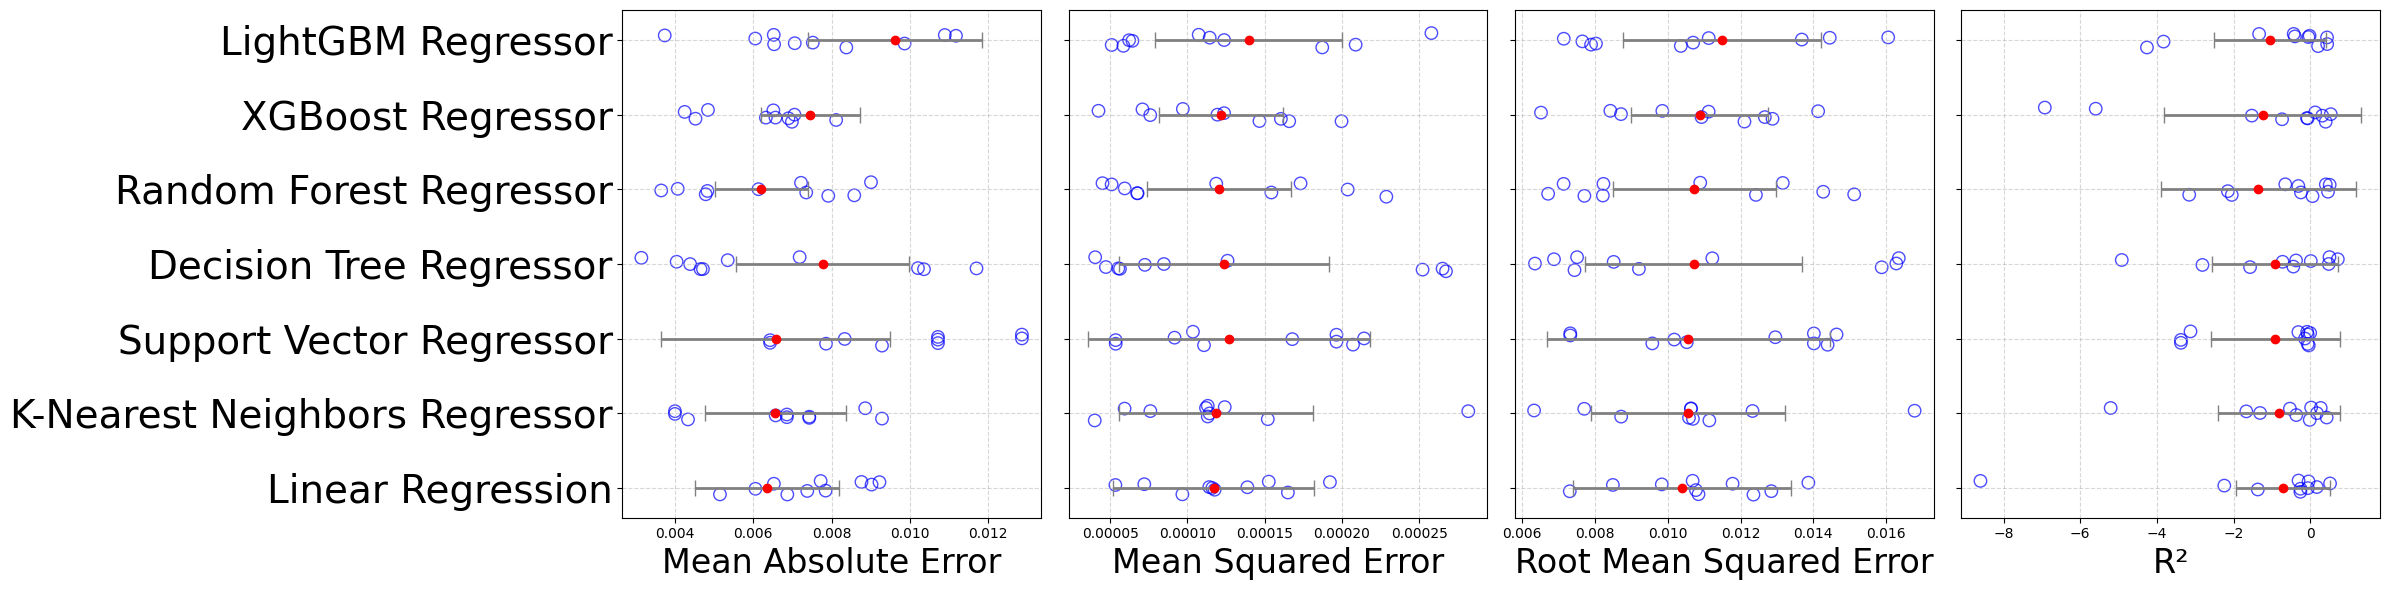

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics         import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model    import (
    LinearRegression, Lasso, ElasticNet
)
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (
    RandomForestRegressor, GradientBoostingRegressor
)
import xgboost as xgb
import lightgbm as lgb

# ── UPDATED MODEL LIST ────────────────────────────────────────────────────────
models = [
    # plain linear baseline
    ("Linear Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LinearRegression())
    ])),

    # polynomial features + linear
    # ("Polynomial (deg=2) + LR", Pipeline([
    #     ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    #     ("scaler", StandardScaler()),
    #     ("lr",     LinearRegression())
    # ])),

    # Lasso for L1 regularization
    # ("Lasso Regression", Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("lasso",  Lasso(alpha=0.001, random_state=42))
    # ])),

    # ElasticNet for combined L1/L2
    # ("ElasticNet", Pipeline([
    #     ("scaler",    StandardScaler()),
    #     ("elastic",   ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42))
    # ])),

    ("K-Nearest Neighbors Regressor", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", KNeighborsRegressor())
    ])),

    # Support Vector Regressor (tune kernel/C/gamma as needed)
    ("Support Vector Regressor", Pipeline([
        ("scaler", StandardScaler()),
        ("svr",    SVR(kernel="rbf", C=1.0, gamma="scale"))
    ])),

    # Simple tree
    ("Decision Tree Regressor", DecisionTreeRegressor(
        max_depth=5, min_samples_leaf=5, random_state=42
    )),

    # Ensemble of trees
    ("Random Forest Regressor", RandomForestRegressor(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=42
    )),

    # # Gradient Boosting
    # ("Gradient Boosting Regressor", GradientBoostingRegressor(
    #     n_estimators=200, learning_rate=0.05,
    #     max_depth=3, random_state=42
    # )),

    ("XGBoost Regressor", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42
    )),

    ("LightGBM Regressor", lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=-1, random_state=42
    )),
]
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds = 10

# ── 3) CROSS-VALIDATE EACH MODEL ─────────────────────────────────────────────
cv_results = {}
for name, model in models:
    print(f"Running CV for {name}")
    res = cross_validate(
        model, X_train, y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    # Convert negative scorers back to positive
    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals = res["test_R2"]

    cv_results[name] = {
        "MAE":  mae_vals,
        "MSE":  mse_vals,
        "RMSE": rmse_vals,
        "R2":   r2_vals
    }

# ── 4) BUILD SUMMARY DataFrame ───────────────────────────────────────────────
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model":     name,
        "MAE Mean":  scores["MAE"].mean(),
        "MAE Std":   scores["MAE"].std(),
        "MSE Mean":  scores["MSE"].mean(),
        "MSE Std":   scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std":  scores["RMSE"].std(),
        "R2 Mean":   scores["R2"].mean(),
        "R2 Std":    scores["R2"].std(),
    })

summary_df = (
    pd.DataFrame(summary_rows)
      .set_index("Model")
      .sort_values("RMSE Mean")  # optional: sort by best RMSE
)
print("\nCross-Validation Summary:\n", summary_df)

# ── 5) PLOT FOLD SCORES + MEAN ± STD ────────────────────────────────────────
metrics    = ["MAE", "MSE", "RMSE", "R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 6), sharey=True)

for ax, metric in zip(axes, metrics):
    # Plot each fold’s score with a small vertical jitter
    for idx, (name, _) in enumerate(models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(
            vals,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=80
        )

    # Plot mean ± std at exact y positions
    means = summary_df[f"{metric} Mean"]
    stds  = summary_df[f"{metric} Std"]
    ax.errorbar(
        means.values,
        np.arange(len(models)),
        xerr=stds.values,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels([name for name, _ in models], fontsize=28)
    ax.set_xlabel(xlabel_map[metric], fontsize=24)
    ax.grid(True, linestyle="--", alpha=0.5)

    # Invert x-axis for error metrics
    #if metric in ("MAE", "MSE", "RMSE"):
    #    ax.invert_xaxis()

plt.tight_layout()
plt.show()


Hyperparameter tuning

In [ ]:


from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

# 1) Define the estimator
lgbm = LGBMRegressor(random_state=42)

# 2) Define hyperparameter distributions
param_dist = {
    "n_estimators":    [100, 200, 500, 1000],
    "learning_rate":   [0.01, 0.03, 0.05, 0.1],
    "num_leaves":      [31, 50, 100, 200],
    "max_depth":       [-1, 5, 10, 20],
    "subsample":       [0.6, 0.8, 1.0],
    "colsample_bytree":[0.6, 0.8, 1.0],
    "min_child_samples":[5, 10, 20, 50]
}

# 3) Set up RandomizedSearchCV
rnd_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,               # number of random combinations to try
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4) Fit on your training data
rnd_search.fit(X_train, y_train)

print("Best parameters:", rnd_search.best_params_)
print("Best RMSE (CV):", -rnd_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 69, number of used features: 0
[LightGBM] [Info] Start training from score 0.032101
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

Feature engineering

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_train)

# Now X_poly has all pairwise interactions; you can plug it into your tuned model:
rnd_search.best_estimator_.fit(X_poly, y_train)


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 69, number of used features: 0
[LightGBM] [Info] Start training from score 0.032101
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spli

LGBMRegressor(learning_rate=0.03, max_depth=5, min_child_samples=50,
              n_estimators=200, num_leaves=200, random_state=42, subsample=0.8)

Target transformation

In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

log_pipe = make_pipeline(
    FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True),
    rnd_search.best_estimator_
)

# Cross‐validate on the log scale, scoring on original scale:
from sklearn.metrics import make_scorer, mean_squared_error

def rmse_orig(y_true, y_pred_log):
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))

log_pipe.fit(X_train, y_train)
cv_score = cross_val_score(log_pipe, X_train, y_train, cv=5,
                           scoring=make_scorer(rmse_orig, greater_is_better=False))
print("Log‐pipe RMSE:", -cv_score.mean())


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 69, number of used features: 0
[LightGBM] [Info] Start training from score 0.032101
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spli

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, b

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

poly_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2,
                                interaction_only=True,
                                include_bias=False)),
    ("model", lgbm)
])

# Evaluate on R² (or RMSE) with CV
scores = cross_val_score(poly_pipeline, X_train, y_train,
                         scoring="r2", cv=5, n_jobs=-1)
print("Polynomial pipeline R²:", scores.mean(), "±", scores.std())


Polynomial pipeline R²: -0.5145371835558701 ± 0.7323530677368227


In [ ]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_val_score

ttr = TransformedTargetRegressor(
    regressor   = lgbm,
    transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1),
)

# Evaluate on RMSE (negative sign for scorer)
scores = cross_val_score(
    ttr, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
print("Log-target RMSE:", -scores.mean(), "±", scores.std())
print("Log-target R²:", cross_val_score(ttr, X_train, y_train,
                                        scoring="r2", cv=5).mean())


Log-target RMSE: 0.011263254183180433 ± 0.0014292536071381162
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117
[LightGBM] [Info] Number of data points in the train set: 55, number of used features: 9
[LightGBM] [Info] Start training from score 0.030479
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

Robust Regression

In [ ]:
from sklearn.linear_model import HuberRegressor

huber_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("huber", HuberRegressor(alpha=0.1, max_iter=1000))
])

# Tune alpha via GridSearchCV if needed
huber_pipe.fit(X_train, y_train)
print("Huber R²:", huber_pipe.score(X_test, y_test))


Huber R²: 0.004705093645082203


In [ ]:
from sklearn.model_selection import cross_val_score

pipelines = {
    "LGBM (tuned)": lgbm,
    "LGBM + poly": poly_pipeline,
    "LGBM + log target": ttr,
    "Huber": huber_pipe
}

for name, pipe in pipelines.items():
    r2 = cross_val_score(pipe, X_train, y_train,
                         scoring="r2", cv=5, n_jobs=-1)
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring="neg_root_mean_squared_error",
                            cv=5, n_jobs=-1)
    print(f"{name:20s} → R² = {r2.mean():.4f} ± {r2.std():.4f}, "
          f"RMSE = {rmse.mean():.4f} ± {rmse.std():.4f}")

LGBM (tuned)         → R² = -0.5033 ± 0.7687, RMSE = 0.0113 ± 0.0014
LGBM + poly          → R² = -0.5145 ± 0.7324, RMSE = 0.0114 ± 0.0021
LGBM + log target    → R² = -0.4967 ± 0.7540, RMSE = 0.0113 ± 0.0014
Huber                → R² = -0.9134 ± 1.5701, RMSE = 0.0119 ± 0.0021


Permutation importance

In [ ]:
from sklearn.inspection import permutation_importance

best = rnd_search.best_estimator_
best.fit(X_train, y_train)
perm = permutation_importance(best, X_train, y_train,
                              scoring="r2", n_repeats=10, random_state=0)
imp = pd.Series(perm.importances_mean, index=X_train.columns)
keep = imp[imp > 0].sort_values(ascending=False).index
X_pruned = X_train[keep]
print("Keeping:", list(keep))


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 69, number of used features: 0
[LightGBM] [Info] Start training from score 0.032101
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spli

In [ ]:
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import TransformedTargetRegressor

pt = PowerTransformer(method="yeo-johnson")
ttr = TransformedTargetRegressor(regressor=best, transformer=pt)

scores = cross_val_score(ttr, X_train, y_train,
                         scoring="r2", cv=5, n_jobs=-1)
print("Yeo–Johnson R²:", scores.mean(), "±", scores.std())


Yeo–Johnson R²: -0.16704431990423285 ± 0.12436210828411096


In [ ]:
lgb_robust = lgb.LGBMRegressor(**rnd_search.best_params_, objective="regression_l1")
scores = cross_val_score(lgb_robust, X_train, y_train,
                         scoring="r2", cv=5, n_jobs=-1)
print("L1‐objective R²:", scores.mean(), "±", scores.std())


L1‐objective R²: -0.1294798504674038 ± 0.1026944238509533


In [ ]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ("lgbm", rnd_search.best_estimator_),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=0)),
    ("svr", SVR())
]
stack = StackingRegressor(estimators=estimators,
                          final_estimator=LinearRegression())
print("Stack R²:",
      cross_val_score(stack, X_train, y_train,
                      scoring="r2", cv=5, n_jobs=-1).mean())


Stack R²: -0.3410966028649984


Evaluating Linear Regression with 10-fold cross-validation...
Evaluating SVR with 10-fold cross-validation...
Evaluating KNN with 10-fold cross-validation...
Evaluating Decision Tree with 10-fold cross-validation...
Evaluating Random Forest with 10-fold cross-validation...


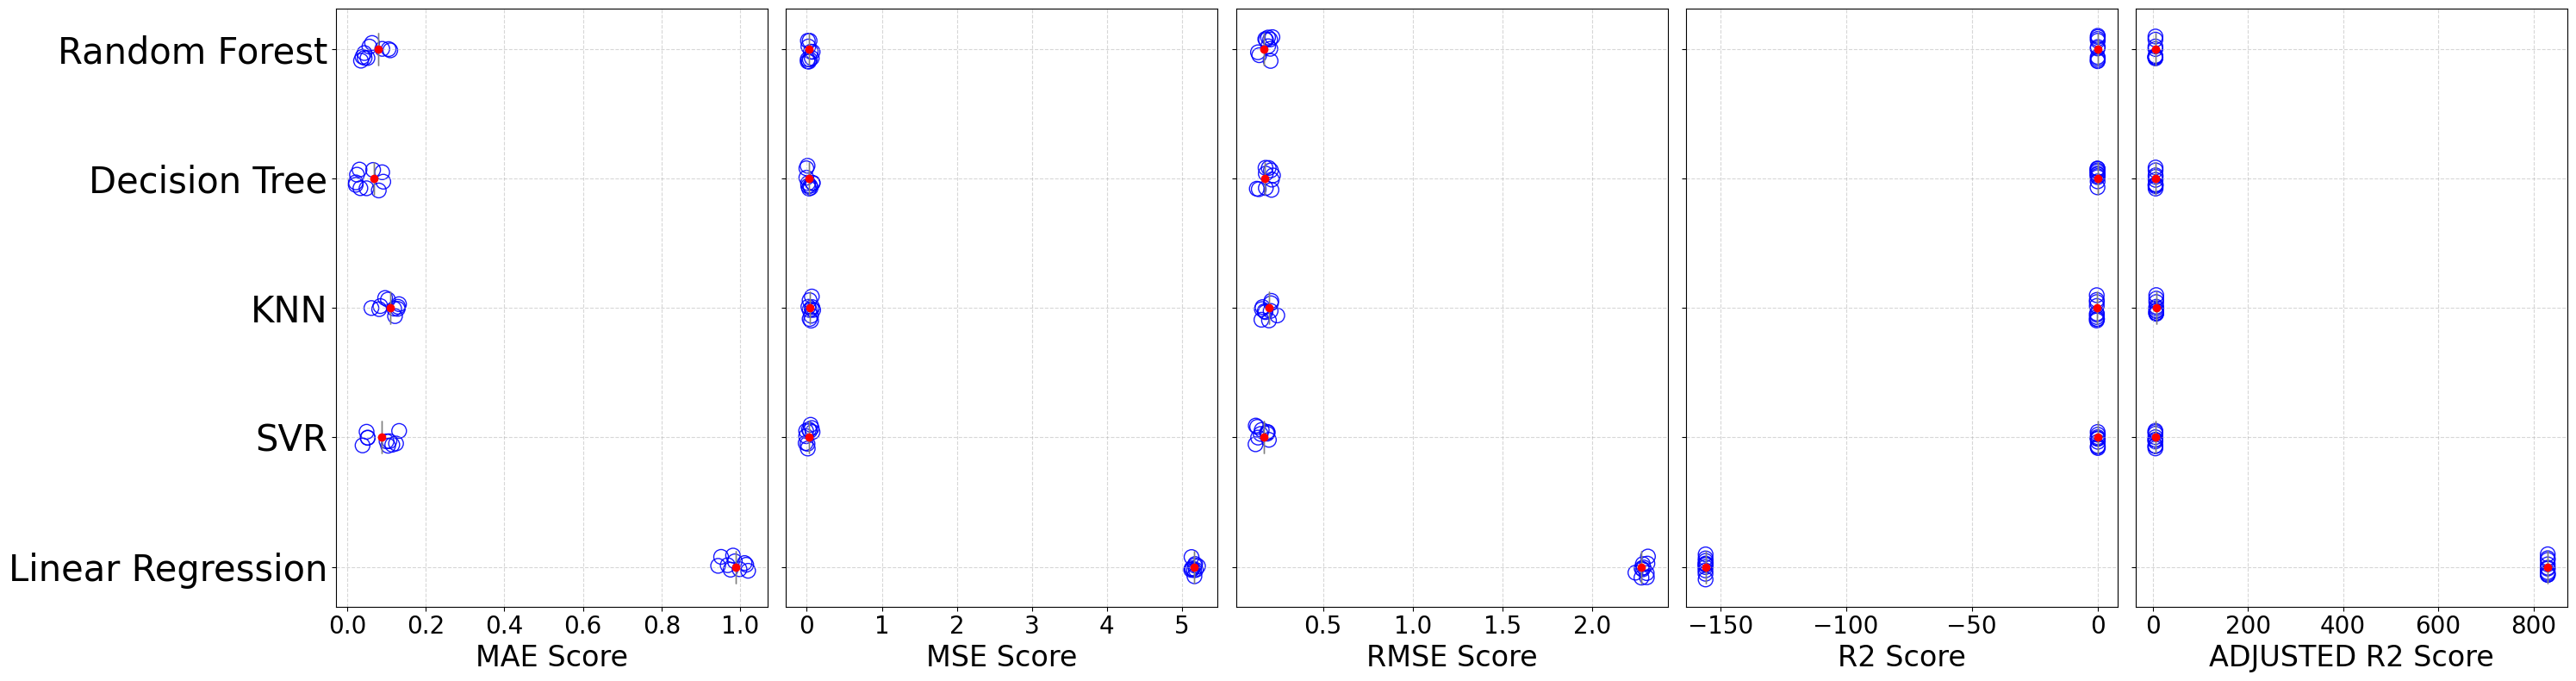

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models = [
    ("Linear Regression", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", LinearRegression())
    ])),
    ("SVR", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", SVR())
    ])),
    ("KNN", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", KNeighborsRegressor())
    ])),
    ("Decision Tree", DecisionTreeRegressor(random_state=42)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42))
]

# Collect results for each model and each metric
scoring_metrics = ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2']
results = {metric: [] for metric in scoring_metrics}
all_scores = []

cv_folds = 10
n_samples, n_features = X_train.shape

for name, model in models:
    print(f"Evaluating {name} with {cv_folds}-fold cross-validation...")
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv_folds)

    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train, y_pred)
    adjusted_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    explained_var = explained_variance_score(y_train, y_pred)

    results['MAE'].append({'Model': name, 'Mean Score': mae, 'Std Dev': 0})  
    results['MSE'].append({'Model': name, 'Mean Score': mse, 'Std Dev': 0})
    results['RMSE'].append({'Model': name, 'Mean Score': rmse, 'Std Dev': 0})
    results['R2'].append({'Model': name, 'Mean Score': r2, 'Std Dev': 0})
    results['Adjusted R2'].append({'Model': name, 'Mean Score': adjusted_r2, 'Std Dev': 0})

    all_scores.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adjusted_r2,
        'Explained Variance': explained_var
    })

# Convert results to DataFrames
results_df = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame([score for metric_scores in all_scores for metric, score in metric_scores.items() if metric in scoring_metrics])

# Create subplots for different metrics
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=True)

for ax, metric in zip(axes, scoring_metrics):
    metric_results_df = results_df[metric]
    for i, model in enumerate(metric_results_df['Model']):
        # Generate random scores to simulate cross-validation distribution (use actual CV results if available)
        scores = [metric_results_df.loc[metric_results_df['Model'] == model, 'Mean Score'].values[0] + np.random.uniform(-0.05, 0.05) for _ in range(cv_folds)]
        jittered_positions = [i + (np.random.uniform(-0.1, 0.1)) for _ in range(len(scores))]
        ax.scatter(scores, jittered_positions, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score with error bars
    ax.errorbar(metric_results_df['Mean Score'], range(len(metric_results_df['Model'])),
                xerr=metric_results_df['Std Dev'], fmt='o', color='red', ecolor='gray',
                elinewidth=2, capsize=14, label='Mean ± Std Dev')

    # Customize each subplot
    ax.set_yticks(range(len(metric_results_df['Model'])))
    ax.set_yticklabels(metric_results_df['Model'], fontsize=30)
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

# ── assume you already have X_train, y_train and your best_model from RandomizedSearchCV ──

# 1) Copy the original training features
X_dom = X_train.copy()

# 2) Seasonal precipitation indices
#    (find all your per-month precipitation columns by pattern)
prec_cols = [c for c in X_dom.columns if "prec" in c]  
X_dom["prec_mean"]       = X_dom[prec_cols].mean(axis=1)
X_dom["prec_std"]        = X_dom[prec_cols].std(axis=1)
X_dom["prec_cv"]         = X_dom["prec_std"] / X_dom["prec_mean"]                # coefficient of variation
X_dom["prec_seasonality"] = (
    X_dom[prec_cols].max(axis=1) - X_dom[prec_cols].min(axis=1)
) / X_dom["prec_mean"]

# 3) Temperature seasonality
#    (similarly, find your monthly TMAX / TMIN columns)
tmax_cols = [c for c in X_dom.columns if "tmax" in c]
tmin_cols = [c for c in X_dom.columns if "tmin" in c]
X_dom["tmax_mean"]       = X_dom[tmax_cols].mean(axis=1)
X_dom["tmin_mean"]       = X_dom[tmin_cols].mean(axis=1)
X_dom["temp_amp"]        = X_dom[tmax_cols].max(axis=1) - X_dom[tmin_cols].min(axis=1)

# 4) Soil × Vegetation interaction
#    (if you have one-hot columns for soil types and vegetation)
soil_cols = [c for c in X_dom.columns if c.startswith("env_76_soi")]
veg_cols  = [c for c in X_dom.columns if c.startswith("veg_")]  # adjust prefix
for s in soil_cols:
    for v in veg_cols:
        X_dom[f"{s}__{v}"] = X_dom[s] * X_dom[v]

# 5) Spatial clustering by latitude/longitude
if {"latitude","longitude"}.issubset(X_dom.columns):
    coords = X_dom[["latitude","longitude"]]
    km = KMeans(n_clusters=5, random_state=0).fit(coords)
    X_dom["site_cluster"] = km.labels_
    X_dom = pd.get_dummies(X_dom, columns=["site_cluster"], prefix="cluster")

# 6) PCA summary of highly‐collinear predictors
#    (choose a block of features you suspect are redundant)
block = [c for c in X_dom.columns if c.startswith("env_")]  # e.g. all environmental
pca = PCA(n_components=3, random_state=0).fit(X_dom[block])
pcs = pca.transform(X_dom[block])
for i in range(pcs.shape[1]):
    X_dom[f"pca_env_{i+1}"] = pcs[:, i]

# 7) Re-evaluate your tuned LGBM on this expanded set
scores_r2   = cross_val_score(lgbm, X_dom, y_train, scoring="r2", cv=5, n_jobs=-1)
scores_rmse = -cross_val_score(lgbm, X_dom, y_train,
                               scoring="neg_root_mean_squared_error",
                               cv=5, n_jobs=-1)

print(f"With domain features → R² = {scores_r2.mean():.4f} ± {scores_r2.std():.4f}")
print(f"With domain features → RMSE = {scores_rmse.mean():.4f} ± {scores_rmse.std():.4f}")


With domain features → R² = -0.5090 ± 0.7680
With domain features → RMSE = 0.0113 ± 0.0014


In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
import lightgbm as lgb

# 1) Generate X_dom exactly as before (seasonality, soil×veg, PCA, clusters…)
#    (re-use the X_dom you built)

# 2) Build the L1‐objective model with your best hyperparameters
l1_params = {
    "learning_rate": 0.03,
    "max_depth": 5,
    "min_child_samples": 50,
    "n_estimators": 200,
    "num_leaves": 200,
    "subsample": 0.8,
    "colsample_bytree": 1.0,
    "objective": "regression_l1",
    "random_state": 42
}
lgb_l1 = lgb.LGBMRegressor(**l1_params)

# 3) CV-evaluate on the expanded feature set
r2 = cross_val_score(lgb_l1, X_dom, y_train, scoring="r2", cv=5, n_jobs=-1)
rmse = -cross_val_score(
    lgb_l1, X_dom, y_train,
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)

print(f"L1‐objective + domain → R² = {r2.mean():.4f} ± {r2.std():.4f}")
print(f"L1‐objective + domain → RMSE = {rmse.mean():.4f} ± {rmse.std():.4f}")


L1‐objective + domain → R² = -0.1295 ± 0.1027
L1‐objective + domain → RMSE = 0.0107 ± 0.0031


In [ ]:
from sklearn.cross_decomposition import PLSRegression
n_components=5
pls = PLSRegression(n_components)
r2_pls = cross_val_score(pls, X_train, y_train, scoring="r2", cv=5, n_jobs=-1)
rmse_pls = -cross_val_score(
    pls, X_train, y_train,
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)

print(f"PLS ({n_components} comps) → R² = {r2_pls.mean():.4f} ± {r2_pls.std():.4f}")
print(f"PLS ({n_components} comps) → RMSE = {rmse_pls.mean():.4f} ± {rmse_pls.std():.4f}")


PLS (5 comps) → R² = -0.6829 ± 1.1829
PLS (5 comps) → RMSE = 0.0112 ± 0.0006


tuning

In [ ]:
import numpy  as np
import pandas as pd

# scikit-learn imports
from sklearn.model_selection   import train_test_split
from sklearn.ensemble          import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import (
    roc_auc_score,
    mean_absolute_error,
    classification_report
)

# -----------------------------------------------------------------------------
#  0) Assume you already have your DataFrame `coffee_data` with columns:
#      - 'caffeine_class'   (0 or 1)
#      - 'caffeine_percent' (numeric, zero for class 0)
#      - all the predictor columns
# -----------------------------------------------------------------------------

# 1) Carve X, y_class, y_amount
X       = coffee_data.drop(["caffeine_class","caffeine_percent"], axis=1)
y_class = coffee_data["caffeine_class"]
y_amt   = coffee_data["caffeine_percent"]

# 2) Single train/test split on the full data
X_train, X_test, ycl_tr, ycl_te, yamt_tr, yamt_te = train_test_split(
    X, y_class, y_amt,
    test_size=0.20,
    stratify=y_class,    # preserve class balance
    random_state=42
)

# -----------------------------------------------------------------------------
#  3) Stage 1: Train a classifier on ALL training rows
# -----------------------------------------------------------------------------
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, ycl_tr)

# Evaluate classification
probs     = clf.predict_proba(X_test)[:,1]
pred_class= (probs >= 0.5).astype(int)

print("\n=== Stage 1: Classification ===")
print(f"ROC-AUC: {roc_auc_score(ycl_te, probs):.3f}")
print(classification_report(ycl_te, pred_class, digits=3))

# -----------------------------------------------------------------------------
#  4) Stage 2: Subset the *same* training split to positives only
# -----------------------------------------------------------------------------
pos_train_mask = (ycl_tr == 1)
pos_test_mask  = (ycl_te == 1)

Xreg_tr = X_train[pos_train_mask]
yreg_tr = yamt_tr[pos_train_mask]

Xreg_te = X_test[pos_test_mask]
yreg_te = yamt_te[pos_test_mask]

# 5) Train a regressor on those positives
reg = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
reg.fit(Xreg_tr, yreg_tr)

# Evaluate regression on the positive hold-out
yreg_pred = reg.predict(Xreg_te)
mae_pos   = mean_absolute_error(yreg_te, yreg_pred)
print("\n=== Stage 2: Regression on Positives ===")
print(f"MAE (positive samples only): {mae_pos:.3f} % caffeine")

# -----------------------------------------------------------------------------
#  6) (Optional) Combine for an overall pipeline MAE
# -----------------------------------------------------------------------------
yamt_pred_full = np.zeros(len(X_test), dtype=float)
yamt_pred_full[pos_test_mask] = yreg_pred

overall_mae = mean_absolute_error(yamt_te, yamt_pred_full)
print(f"Overall MAE (includes true zeroes): {overall_mae:.3f} % caffeine")



=== Stage 1: Classification ===
ROC-AUC: 0.867
              precision    recall  f1-score   support

           0      0.867     0.915     0.890        71
           1      0.600     0.474     0.529        19

    accuracy                          0.822        90
   macro avg      0.733     0.695     0.710        90
weighted avg      0.810     0.822     0.814        90


=== Stage 2: Regression on Positives ===
MAE (positive samples only): 0.096 % caffeine
Overall MAE (includes true zeroes): 0.020 % caffeine


Drop outliers (0.8 vs next largest 0.035)

In [ ]:
# after you carve out the positives:
df_pos = coffee_data[coffee_data.caffeine_class == 1].copy()

# 1) drop anything above, say, 0.1% (or 0.05%, whatever makes sense)
cutoff = 0.1
df_pos_trunc = df_pos[df_pos.caffeine_percent <= cutoff]

# 2) rebuild X_reg, y_reg from the truncated positives
X_trunc = df_pos_trunc.drop(["caffeine_class","caffeine_percent"], axis=1)
y_trunc = df_pos_trunc["caffeine_percent"]

# 3) retrain & CV just on these (inside your two-stage pipeline you
#    would use Xreg_train = X_train[pos & <=cutoff], etc.)
from sklearn.model_selection import cross_val_score
reg = Pipeline([("scaler",StandardScaler()),
                ("rf",    RandomForestRegressor(n_estimators=100, random_state=42))])

scores = -cross_val_score(reg, X_trunc, y_trunc,
                          cv=10,
                          scoring="neg_mean_absolute_error",
                          n_jobs=-1)
print("CV MAE without extremes:", scores.mean(), "±", scores.std())


CV MAE without extremes: 0.008526587812650303 ± 0.008112165696610111


Cap outliers

In [ ]:
# instead of dropping, cap them at the 95th‐percentile of positives
p95 = df_pos.caffeine_percent.quantile(0.95)
df_pos_cap = df_pos.copy()
df_pos_cap["caffeine_percent"] = df_pos_cap["caffeine_percent"].clip(upper=p95)

# rebuild X/y and re‐CV as above
X_cap = df_pos_cap.drop(["caffeine_class","caffeine_percent"], axis=1)
y_cap = df_pos_cap["caffeine_percent"]

scores_cap = -cross_val_score(reg, X_cap, y_cap,
                              cv=10,
                              scoring="neg_mean_absolute_error",
                              n_jobs=-1)
print("CV MAE with winsorization:", scores_cap.mean(), "±", scores_cap.std())


CV MAE with winsorization: 0.08206720060587558 ± 0.11270389071847725


log-transforming target

In [ ]:
from sklearn.compose         import TransformedTargetRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_val_score

# 1) Build a pipeline with a log1p target transform
reg_log = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", StandardScaler()),
        ("rf",     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    func=np.log1p,             # y' = log(1+y)
    inverse_func=np.expm1      # y = exp(y') - 1
)

# 2) Cross-validate on only the positives
mask = (y_amt > 0)
scores_log = -cross_val_score(
    reg_log,
    X[mask], y_amt[mask],
    cv=10,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
print(f"Log-transform CV MAE: {scores_log.mean():.4f} ± {scores_log.std():.4f}")


Log-transform CV MAE: 0.0748 ± 0.1132


Robost regressor

In [ ]:
from sklearn.linear_model    import HuberRegressor
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_val_score

reg_huber = Pipeline([
    ("scaler", StandardScaler()),
    ("huber",  HuberRegressor(epsilon=1.5, max_iter=1000))
])

scores_huber = -cross_val_score(
    reg_huber,
    X[mask], y_amt[mask],
    cv=10,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
print(f"HuberRegressor CV MAE: {scores_huber.mean():.4f} ± {scores_huber.std():.4f}")


HuberRegressor CV MAE: 0.0822 ± 0.1137


CV on RF (raw)…
CV on RF (log-transformed)…
CV on HuberRegressor…
CV on GBR (Huber loss)…

CV MAE on positives only:
                      MAE Mean   MAE Std
Model                                   
RF (raw)              0.082067  0.112704
RF (log-transformed)  0.074757  0.113157
HuberRegressor        0.082188  0.113744
GBR (Huber loss)      0.063425  0.118982


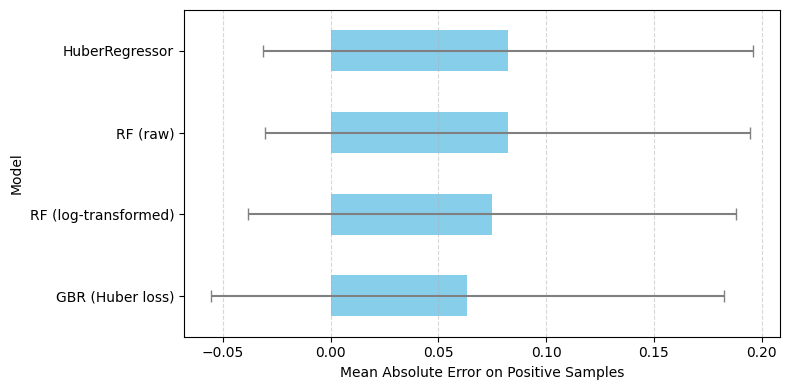

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, PowerTransformer
from sklearn.compose           import TransformedTargetRegressor
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model      import HuberRegressor
from sklearn.metrics           import make_scorer, mean_absolute_error

# 0) Prepare only the caffeinated subset
df_pos = coffee_data[coffee_data.caffeine_class == 1].copy()
X_pos  = df_pos.drop(columns=["caffeine_class","caffeine_percent"])
y_pos  = df_pos["caffeine_percent"]

# 1) Define the four regressors to compare
regs = [
    ("RF (raw)", Pipeline([
        ("scaler", StandardScaler()),
        ("rf",     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])),
    ("RF (log-transformed)", TransformedTargetRegressor(
        regressor=Pipeline([
            ("scaler", StandardScaler()),
            ("rf",     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
        ]),
        func=np.log1p, inverse_func=np.expm1
    )),
    ("HuberRegressor", Pipeline([
        ("scaler", StandardScaler()),
        ("huber",  HuberRegressor(epsilon=1.5, max_iter=1000))
    ])),
    ("GBR (Huber loss)", Pipeline([
        ("scaler", StandardScaler()),
        ("gbr",    GradientBoostingRegressor(
            loss="huber",
            alpha=0.9,
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]))
]

# 2) CV setup: 10-fold MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
cv = 10

# 3) Run CV for each
results = []
for name, reg in regs:
    print(f"CV on {name}…")
    scores = -cross_val_score(
        reg, X_pos, y_pos,
        cv=cv,
        scoring=mae_scorer,
        n_jobs=-1
    )
    results.append((name, scores.mean(), scores.std()))

# 4) Summarize
summary = pd.DataFrame(results, columns=["Model","MAE Mean","MAE Std"]).set_index("Model")
print("\nCV MAE on positives only:")
print(summary)

# 5) (Optional) bar chart of means ± std
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
summary["MAE Mean"].sort_values(ascending=True).plot.barh(
    xerr=summary["MAE Std"], ax=ax, color="skyblue", ecolor="gray", capsize=4
)
ax.set_xlabel("Mean Absolute Error on Positive Samples")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# … (after your Stage-1 classifier and train/test split) …

# carve out the positives in the SAME split
pos_train = (ycl_tr == 1)
pos_test  = (ycl_te == 1)

Xreg_tr = X_train[pos_train]
yreg_tr = yamt_tr[pos_train]
Xreg_te = X_test[pos_test]
yreg_te = yamt_te[pos_test]

# Stage 2: Gradient Boosting with Huber loss
reg = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr",    GradientBoostingRegressor(
        loss="huber",
        alpha=0.9,             # you can tune this
        learning_rate=0.05,    # ditto
        n_estimators=200,
        max_depth=3,
        random_state=42
    ))
])
reg.fit(Xreg_tr, yreg_tr)

# Evaluate on the positive hold-out
yreg_pred = reg.predict(Xreg_te)
mae_pos   = mean_absolute_error(yreg_te, yreg_pred)
print(f"Stage 2 MAE (GBR-Huber on positives): {mae_pos:.3f} % caffeine")

# (Optional) end-to-end MAE
yamt_pred_full = np.zeros(len(X_test))
yamt_pred_full[pos_test] = yreg_pred
print("Overall MAE:", mean_absolute_error(yamt_te, yamt_pred_full))


Stage 2 MAE (GBR-Huber on positives): 0.094 % caffeine
Overall MAE: 0.0198645274471976


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 500}

▶ Evaluating Baseline (mean) (10-fold CV)

▶ Evaluating Linear Regression (10-fold CV)

▶ Evaluating SVR (10-fold CV)

▶ Evaluating KNN (10-fold CV)

▶ Evaluating Decision Tree (10-fold CV)

▶ Evaluating Random Forest (tuned) (10-fold CV)


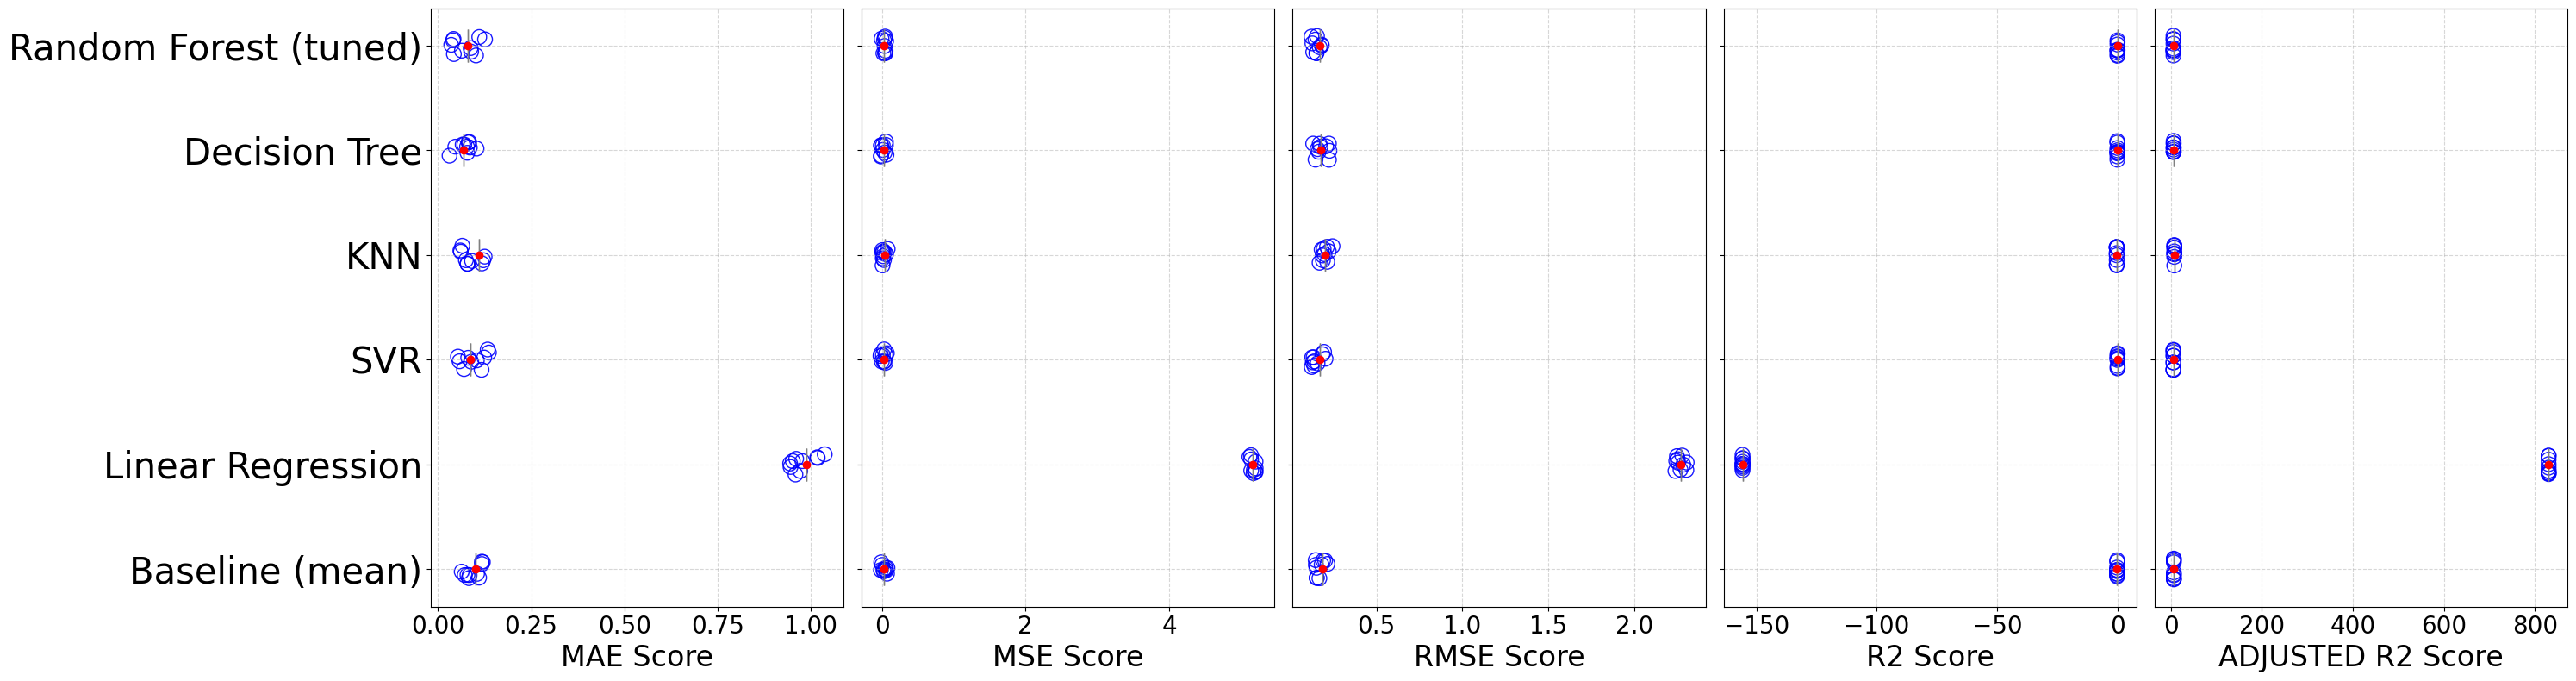

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# ------------------------------------------------------------------------------
# 0) Hyperparameter‐tune the Random Forest with a quick GridSearchCV
# ------------------------------------------------------------------------------
rf_param_grid = {
    'n_estimators': [100, 250, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)
best_rf = gs.best_estimator_
print("Best RF params:", gs.best_params_)

# ------------------------------------------------------------------------------
# 1) Define models – adding a baseline and our tuned RF
# ------------------------------------------------------------------------------
models = [
    ("Baseline (mean)", DummyRegressor(strategy="mean")),
    ("Linear Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])),
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ])),
    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor())
    ])),
    ("Decision Tree", DecisionTreeRegressor(random_state=42)),
    ("Random Forest (tuned)", best_rf)
]

# ------------------------------------------------------------------------------
# 2) Evaluate via cross_val_predict as before
# ------------------------------------------------------------------------------
scoring_metrics = ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2']
results = {m: [] for m in scoring_metrics}
all_scores = []

cv_folds = 10
n_samples, n_features = X_train.shape

for name, model in models:
    print(f"\n▶ Evaluating {name} ({cv_folds}-fold CV)")
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv_folds, n_jobs=-1)

    mae  = mean_absolute_error(y_train, y_pred)
    mse  = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_train, y_pred)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    evs  = explained_variance_score(y_train, y_pred)

    results['MAE'].append({  'Model': name, 'Mean Score': mae,  'Std Dev': 0})
    results['MSE'].append({  'Model': name, 'Mean Score': mse,  'Std Dev': 0})
    results['RMSE'].append({ 'Model': name, 'Mean Score': rmse, 'Std Dev': 0})
    results['R2'].append({   'Model': name, 'Mean Score': r2,   'Std Dev': 0})
    results['Adjusted R2'].append({
                              'Model': name,
                              'Mean Score': adj_r2,
                              'Std Dev': 0})

    all_scores.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adj_r2,
        'Explained Variance': evs
    })

results_df = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame([score for metric_scores in all_scores for metric, score in metric_scores.items() if metric in scoring_metrics])

# Create subplots for different metrics
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=True)

for ax, metric in zip(axes, scoring_metrics):
    metric_results_df = results_df[metric]
    for i, model in enumerate(metric_results_df['Model']):
        # Generate random scores to simulate cross-validation distribution (use actual CV results if available)
        scores = [metric_results_df.loc[metric_results_df['Model'] == model, 'Mean Score'].values[0] + np.random.uniform(-0.05, 0.05) for _ in range(cv_folds)]
        jittered_positions = [i + (np.random.uniform(-0.1, 0.1)) for _ in range(len(scores))]
        ax.scatter(scores, jittered_positions, edgecolor='blue', facecolors='none', alpha=0.9, s=150, label='_nolegend_')

    # Plot the mean score with error bars
    ax.errorbar(metric_results_df['Mean Score'], range(len(metric_results_df['Model'])),
                xerr=metric_results_df['Std Dev'], fmt='o', color='red', ecolor='gray',
                elinewidth=2, capsize=14, label='Mean ± Std Dev')

    # Customize each subplot
    ax.set_yticks(range(len(metric_results_df['Model'])))
    ax.set_yticklabels(metric_results_df['Model'], fontsize=30)
    ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


SVR best params: {'model__C': 1, 'model__gamma': 'scale'}
KNN best params: {'model__n_neighbors': 3}
CV: Baseline
CV: LinReg
CV: SVR
CV: KNN
CV: Decision Tree
CV: Random Forest


C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWar

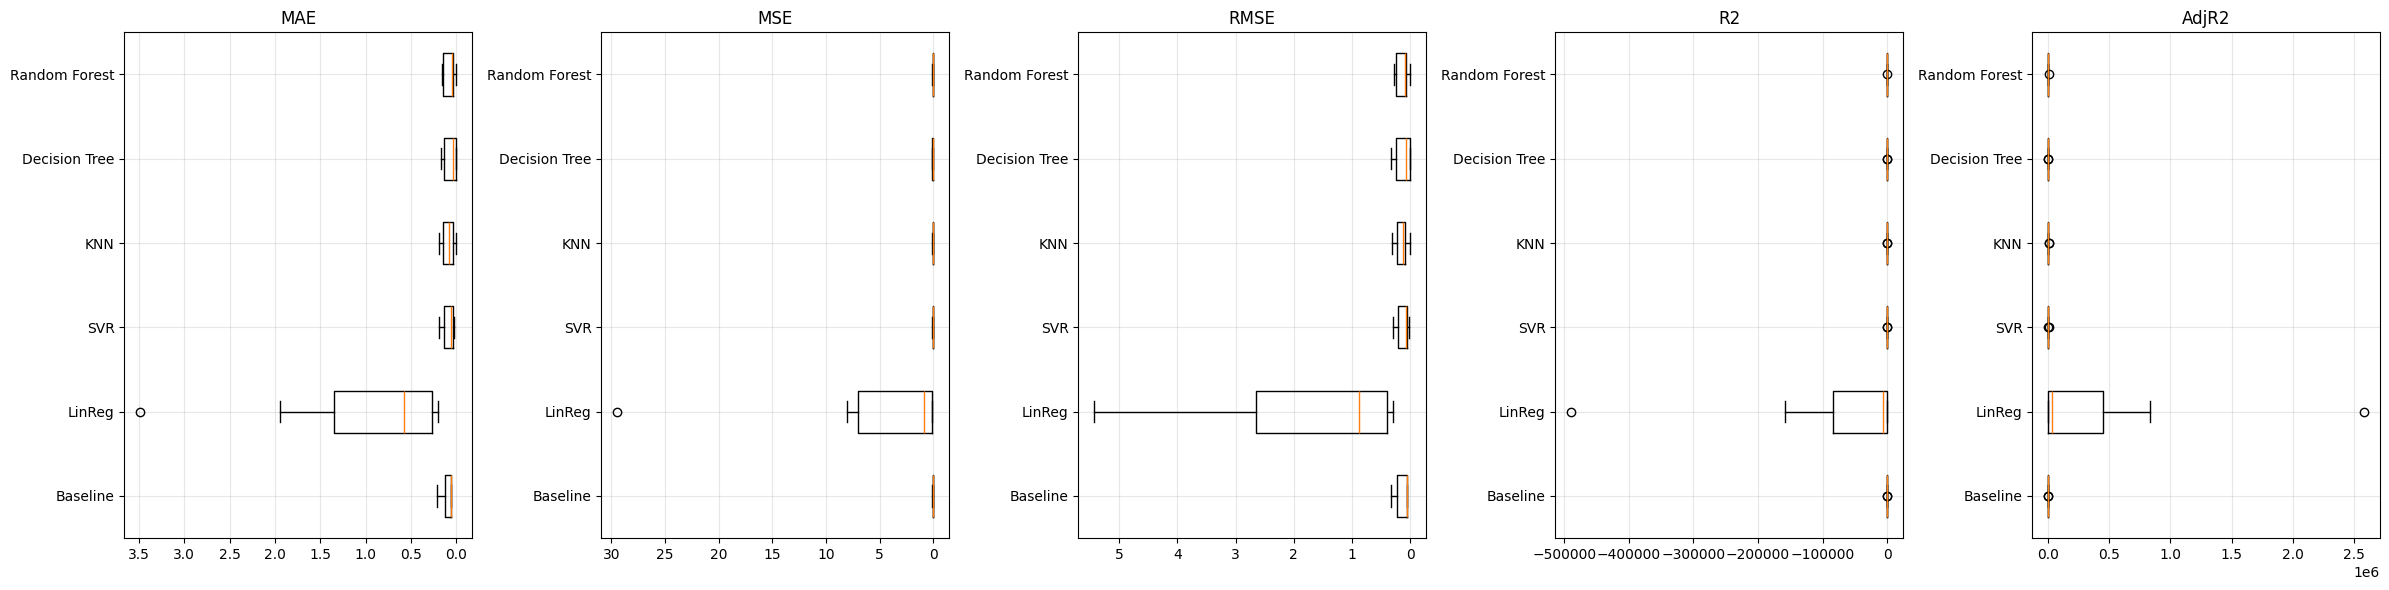

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor

# 1) Define a small helper to compute adjusted R2
def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# 2) Hyperparameter grids for each tunable model
param_grids = {
    'SVR': {'model__C': [0.1, 1, 10], 'model__gamma': ['scale','auto']},
    'KNN': {'model__n_neighbors': [3,5,7,9]},
    'DT' : {'max_depth': [None,5,10,20]},
    'RF' : {'n_estimators':[100,300], 'max_depth':[None,10,20]},
}

# 3) Build your list of (name, estimator) pairs
models = [
    ('Baseline',       DummyRegressor(strategy='mean')),
    ('LinReg',         Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
    ('SVR',            Pipeline([('scaler', StandardScaler()), ('model', SVR())])),
    ('KNN',            Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor())])),
    ('Decision Tree',  DecisionTreeRegressor(random_state=42)),
    ('Random Forest',  RandomForestRegressor(random_state=42))
]

# 4) Tune the SVR, KNN, DT and RF via GridSearchCV
tuned_models = []
for name, est in models:
    if name in param_grids:
        grid = GridSearchCV(est, param_grids[name], cv=5,
                            scoring='neg_mean_squared_error',
                            n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        print(f"{name} best params:", grid.best_params_)
        tuned_models.append((name, grid.best_estimator_))
    else:
        tuned_models.append((name, est))

# 5) Now do a proper cross_validate, capturing per-fold metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2':  'r2'
}

cv_folds = 10
n, p = X_train.shape

panel_data = {m: {} for m in ['MAE','MSE','RMSE','R2','AdjR2']}

for name, est in tuned_models:
    print("CV:", name)
    cvres = cross_validate(est, X_train, y_train,
                           cv=cv_folds, scoring=scoring,
                           return_train_score=False,
                           n_jobs=-1)
    # pull out and flip signs for the errors
    mae_scores = -cvres['test_MAE']
    mse_scores = -cvres['test_MSE']
    rmse_scores = np.sqrt(mse_scores)
    r2_scores  =  cvres['test_R2']
    adj_scores = adj_r2(r2_scores, n, p)

    panel_data['MAE'][name]  = mae_scores
    panel_data['MSE'][name]  = mse_scores
    panel_data['RMSE'][name] = rmse_scores
    panel_data['R2'][name]   = r2_scores
    panel_data['AdjR2'][name]= adj_scores

# 6) Plot boxplots for each metric
metrics = ['MAE','MSE','RMSE','R2','AdjR2']
fig, axes = plt.subplots(1, len(metrics), figsize=(24,6), sharey=False)

for ax, metric in zip(axes, metrics):
    data = [panel_data[metric][name] for name, _ in tuned_models]
    ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
    ax.set_title(metric)
    if metric in ['MAE','MSE','RMSE']:
        ax.invert_xaxis()  # smaller is better
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


SVR best params: {'model__C': 1, 'model__gamma': 'scale'}
KNN best params: {'model__n_neighbors': 3}
CV: Baseline
CV: LinReg
CV: SVR
CV: KNN
CV: Decision Tree
CV: Random Forest


C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2111191224.py:91: MatplotlibDeprecationWar

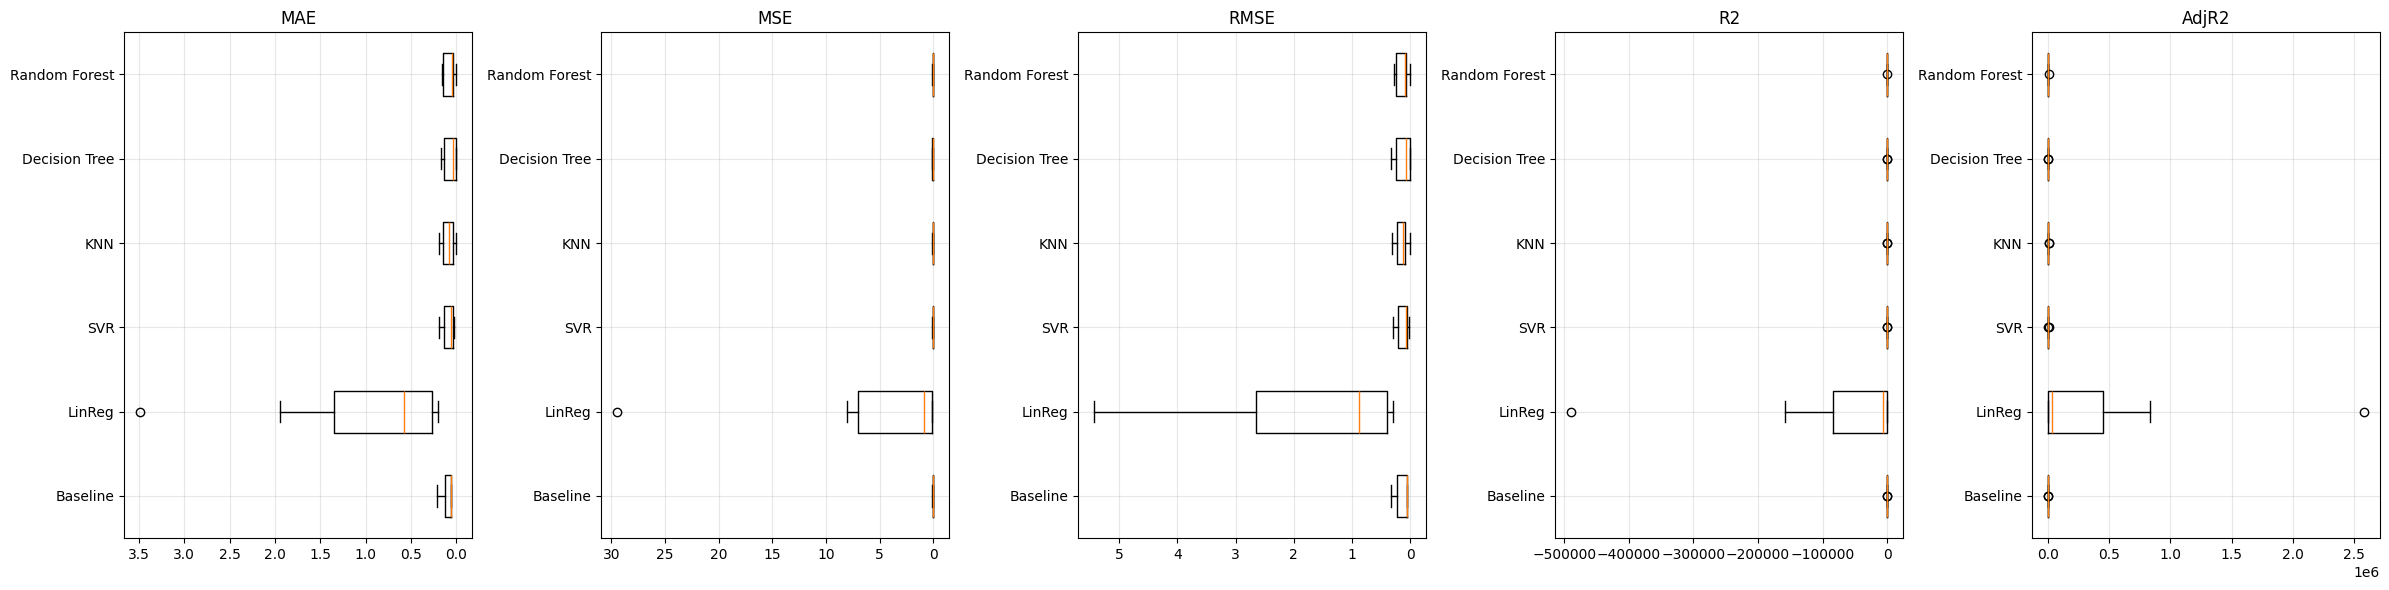

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor

# 1) Define a small helper to compute adjusted R2
def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# 2) Hyperparameter grids for each tunable model
param_grids = {
    'SVR': {'model__C': [0.1, 1, 10], 'model__gamma': ['scale','auto']},
    'KNN': {'model__n_neighbors': [3,5,7,9]},
    'DT' : {'max_depth': [None,5,10,20]},
    'RF' : {'n_estimators':[100,300], 'max_depth':[None,10,20]},
}

# 3) Build your list of (name, estimator) pairs
models = [
    ('Baseline',       DummyRegressor(strategy='mean')),
    ('LinReg',         Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
    ('SVR',            Pipeline([('scaler', StandardScaler()), ('model', SVR())])),
    ('KNN',            Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor())])),
    ('Decision Tree',  DecisionTreeRegressor(random_state=42)),
    ('Random Forest',  RandomForestRegressor(random_state=42))
]

# 4) Tune the SVR, KNN, DT and RF via GridSearchCV
tuned_models = []
for name, est in models:
    if name in param_grids:
        grid = GridSearchCV(est, param_grids[name], cv=5,
                            scoring='neg_mean_squared_error',
                            n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        print(f"{name} best params:", grid.best_params_)
        tuned_models.append((name, grid.best_estimator_))
    else:
        tuned_models.append((name, est))

# 5) Now do a proper cross_validate, capturing per-fold metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2':  'r2'
}

cv_folds = 10
n, p = X_train.shape

panel_data = {m: {} for m in ['MAE','MSE','RMSE','R2','AdjR2']}

for name, est in tuned_models:
    print("CV:", name)
    cvres = cross_validate(est, X_train, y_train,
                           cv=cv_folds, scoring=scoring,
                           return_train_score=False,
                           n_jobs=-1)
    # pull out and flip signs for the errors
    mae_scores = -cvres['test_MAE']
    mse_scores = -cvres['test_MSE']
    rmse_scores = np.sqrt(mse_scores)
    r2_scores  =  cvres['test_R2']
    adj_scores = adj_r2(r2_scores, n, p)

    panel_data['MAE'][name]  = mae_scores
    panel_data['MSE'][name]  = mse_scores
    panel_data['RMSE'][name] = rmse_scores
    panel_data['R2'][name]   = r2_scores
    panel_data['AdjR2'][name]= adj_scores

# 6) Plot boxplots for each metric
metrics = ['MAE','MSE','RMSE','R2','AdjR2']
fig, axes = plt.subplots(1, len(metrics), figsize=(24,6), sharey=False)

for ax, metric in zip(axes, metrics):
    data = [panel_data[metric][name] for name, _ in tuned_models]
    ax.boxplot(data, labels=[n for n,_ in tuned_models], vert=False)
    ax.set_title(metric)
    if metric in ['MAE','MSE','RMSE']:
        ax.invert_xaxis()  # smaller is better
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Tuning SVR…
  Best SVR params: {'model__C': 1, 'model__gamma': 'scale'}
Tuning KNN…
  Best KNN params: {'model__n_neighbors': 3}
Tuning DecisionTree…
  Best DecisionTree params: {'max_depth': None}
Tuning RandomForest…
  Best RandomForest params: {'max_depth': 10, 'n_estimators': 300}
Cross‐validating Baseline…
Cross‐validating LinReg…
Cross‐validating SVR…
Cross‐validating KNN…
Cross‐validating DecisionTree…
Cross‐validating RandomForest…


C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2470416125.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2470416125.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2470416125.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\2470416125.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

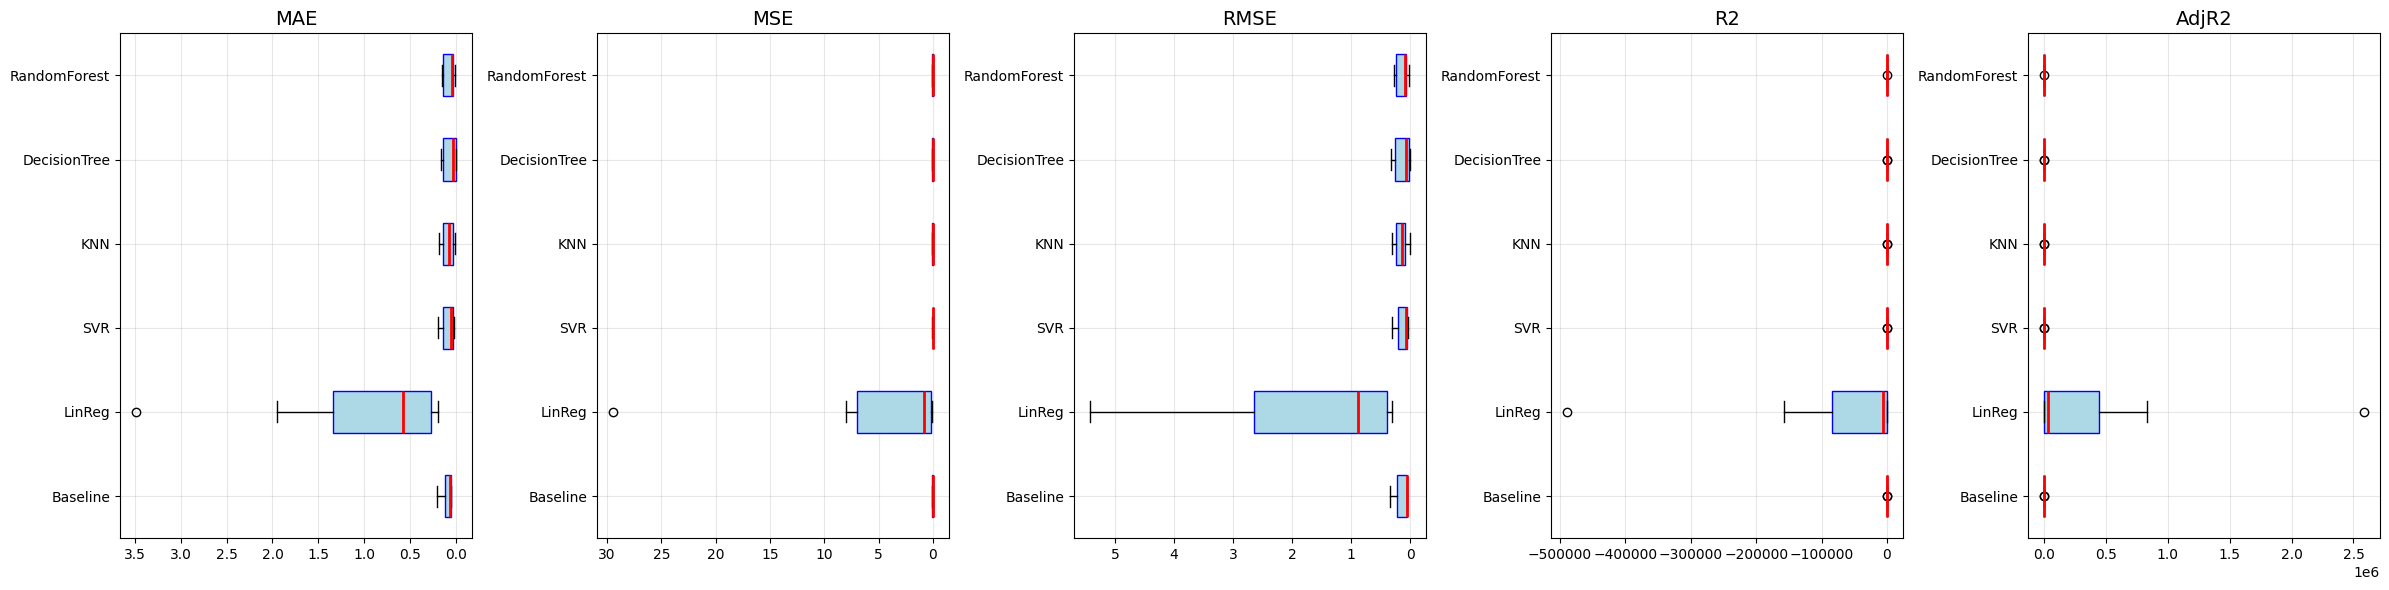

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor

# -----------------------------------------------------------------------------
# 0) Helper to compute adjusted R²
# -----------------------------------------------------------------------------
def adjusted_r2(r2, n_samples, n_features):
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

# -----------------------------------------------------------------------------
# 1) Define raw models and hyperparameter grids
# -----------------------------------------------------------------------------
raw_models = [
    ("Baseline",       DummyRegressor(strategy="mean")),
    ("LinReg",         Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])),
    ("SVR",            Pipeline([("scaler", StandardScaler()), ("model", SVR())])),
    ("KNN",            Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())])),
    ("DecisionTree",   DecisionTreeRegressor(random_state=42)),
    ("RandomForest",   RandomForestRegressor(random_state=42))
]

param_grids = {
    "SVR":          {"model__C": [0.1, 1, 10], "model__gamma": ["scale","auto"]},
    "KNN":          {"model__n_neighbors": [3,5,7,9]},
    "DecisionTree": {"max_depth": [None, 5, 10, 20]},
    "RandomForest": {"n_estimators":[100,300], "max_depth":[None,10,20]}
}

# -----------------------------------------------------------------------------
# 2) Tune each applicable model via GridSearchCV
# -----------------------------------------------------------------------------
tuned_models = []
for name, estimator in raw_models:
    if name in param_grids:
        print(f"Tuning {name}…")
        gs = GridSearchCV(
            estimator,
            param_grids[name],
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            verbose=0
        )
        gs.fit(X_train, y_train)
        print(f"  Best {name} params: {gs.best_params_}")
        tuned_models.append((name, gs.best_estimator_))
    else:
        tuned_models.append((name, estimator))

# -----------------------------------------------------------------------------
# 3) Define scoring dict for cross_validate
# -----------------------------------------------------------------------------
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds = 10
n_samples, n_features = X_train.shape

# -----------------------------------------------------------------------------
# 4) Run cross_validate and collect per-fold metrics
# -----------------------------------------------------------------------------
panel_data = {metric: {} for metric in ["MAE","MSE","RMSE","R2","AdjR2"]}

for name, estimator in tuned_models:
    print(f"Cross‐validating {name}…")
    cvres = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    # extract and flip sign for neg‐MAE/MSE
    mae_scores  = -cvres["test_MAE"]
    mse_scores  = -cvres["test_MSE"]
    rmse_scores = np.sqrt(mse_scores)
    r2_scores   = cvres["test_R2"]
    adjr2_scores = adjusted_r2(r2_scores, n_samples, n_features)

    panel_data["MAE"][name]   = mae_scores
    panel_data["MSE"][name]   = mse_scores
    panel_data["RMSE"][name]  = rmse_scores
    panel_data["R2"][name]    = r2_scores
    panel_data["AdjR2"][name] = adjr2_scores

# -----------------------------------------------------------------------------
# 5) Plot horizontal boxplots for each metric
# -----------------------------------------------------------------------------
metrics = ["MAE","MSE","RMSE","R2","AdjR2"]
fig, axes = plt.subplots(1, len(metrics), figsize=(24, 6), sharey=False)

for ax, metric in zip(axes, metrics):
    data = [panel_data[metric][name] for name, _ in tuned_models]
    ax.boxplot(
        data,
        labels=[name for name, _ in tuned_models],
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", edgecolor="blue"),
        medianprops=dict(color="red", linewidth=2)
    )
    ax.set_title(metric, fontsize=14)
    ax.grid(True, alpha=0.3)
    if metric in ["MAE","MSE","RMSE"]:
        ax.invert_xaxis()    # smaller=better
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


Tuning SVR …
  Best SVR params → {'model__gamma': 'scale', 'model__C': 0.1}
Tuning KNN …
  Best KNN params → {'model__n_neighbors': 11}
Tuning DecisionTree …
  Best DecisionTree params → {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}
Tuning RandomForest …


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 5 is smaller than n_iter=20. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best RandomForest params → {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 30}
Tuning GBR …
  Best GBR params → {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Tuning ExtraTrees …


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best ExtraTrees params → {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
Tuning AdaBoost …
  Best AdaBoost params → {'n_estimators': 200, 'learning_rate': 0.1}
CV → Baseline
CV → LinReg
CV → SVR
CV → KNN
CV → DecisionTree
CV → RandomForest
CV → GBR
CV → ExtraTrees
CV → AdaBoost
CV → Voting
CV → Stacking


C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\4036417883.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\4036417883.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\4036417883.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\adm1\AppData\Local\Temp\ipykernel_26740\4036417883.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

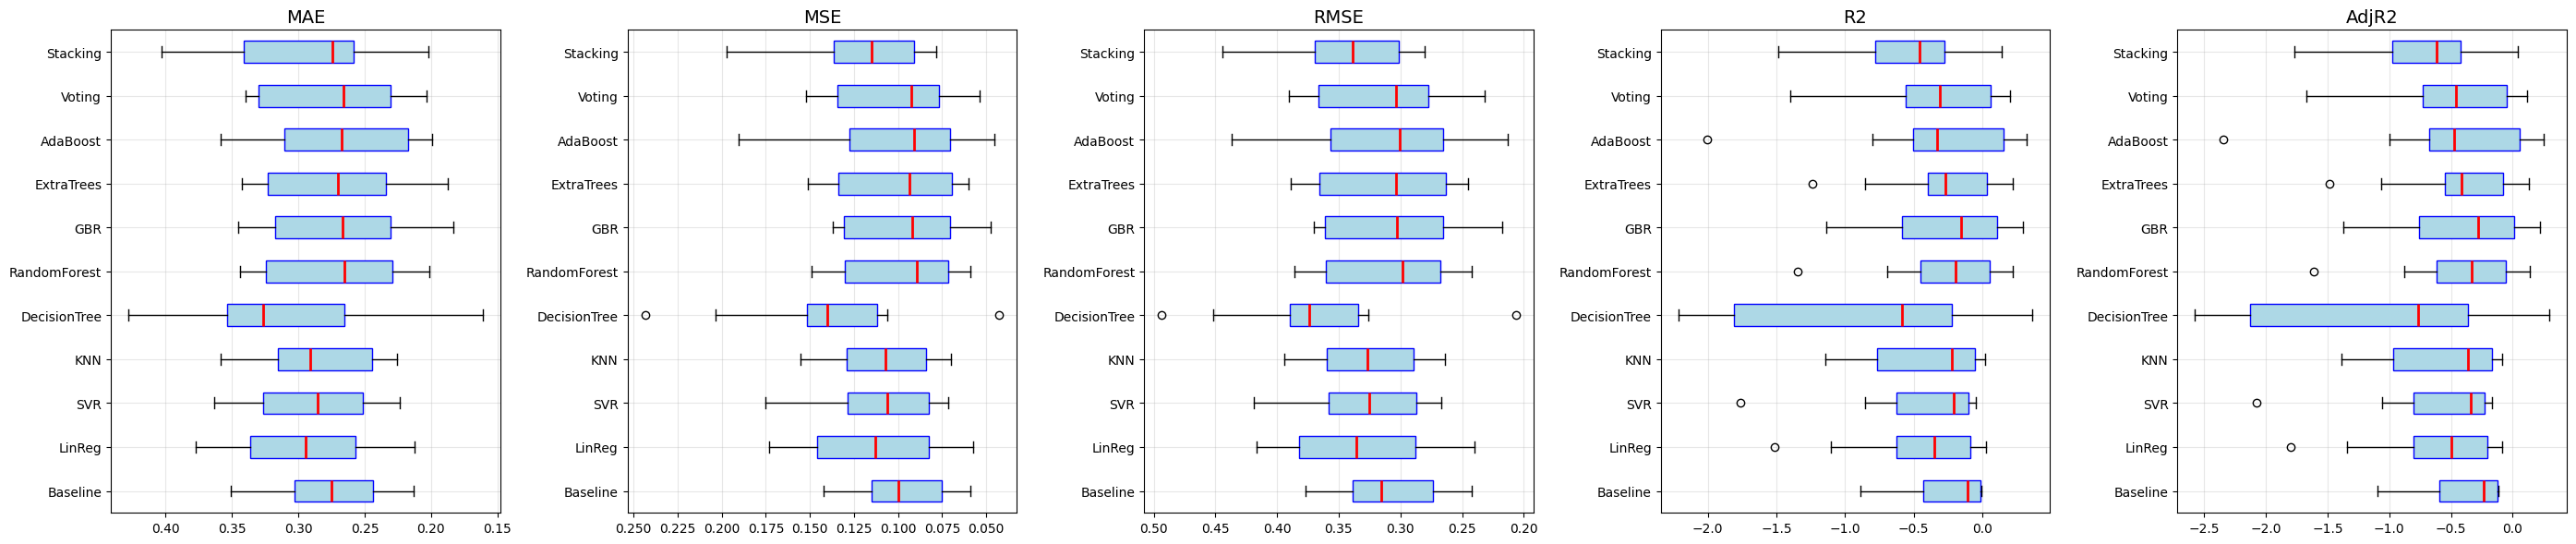

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    VotingRegressor,
    StackingRegressor
)

# -----------------------------------------------------------------------------
# 1) Helper for adjusted R²
# -----------------------------------------------------------------------------
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------------------------------------------------------------
# 2) Define base estimators and their param‐distributions
# -----------------------------------------------------------------------------
estimators = [
    ("Baseline",       DummyRegressor(strategy="mean")),
    ("LinReg",         Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])),
    ("SVR",            Pipeline([("scaler", StandardScaler()), ("model", SVR())])),
    ("KNN",            Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())])),
    ("DecisionTree",   DecisionTreeRegressor(random_state=42)),
    ("RandomForest",   RandomForestRegressor(random_state=42)),
    ("GBR",            GradientBoostingRegressor(random_state=42)),
    ("ExtraTrees",     ExtraTreesRegressor(random_state=42)),
    ("AdaBoost",       AdaBoostRegressor(random_state=42))
]

param_dist = {
    "SVR": {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11]
    },
    "DecisionTree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "RandomForest": {
        "n_estimators": [100, 300, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "GBR": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 10]
    },
    "ExtraTrees": {
        "n_estimators": [100, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0]
    }
}

# -----------------------------------------------------------------------------
# 3) RandomizedSearchCV to tune each model where applicable
# -----------------------------------------------------------------------------
tuned = []
for name, est in estimators:
    if name in param_dist:
        print(f"Tuning {name} …")
        rs = RandomizedSearchCV(
            est,
            param_dist[name],
            n_iter=20,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=42,
            verbose=0
        )
        rs.fit(X_train, y_train)
        print(f"  Best {name} params →", rs.best_params_)
        tuned.append((name, rs.best_estimator_))
    else:
        tuned.append((name, est))

# -----------------------------------------------------------------------------
# 4) Add two ensembles: Voting & Stacking
# -----------------------------------------------------------------------------
# Voting takes the tuned regressors except the baseline
voting = VotingRegressor(
    [(n, m) for n,m in tuned if n != "Baseline"],
    n_jobs=-1
)

# Stacking uses a small final estimator on top
stacking = StackingRegressor(
    estimators=[(n, m) for n,m in tuned if n != "Baseline"],
    final_estimator=GradientBoostingRegressor(random_state=42),
    n_jobs=-1
)

tuned += [("Voting", voting), ("Stacking", stacking)]

# -----------------------------------------------------------------------------
# 5) Cross‐validate all models, capturing per‐fold MAE, MSE & R2
# -----------------------------------------------------------------------------
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds = 10
n_samples, n_features = X_train.shape

# store per‐fold arrays
panel = {metric: {} for metric in ["MAE","MSE","RMSE","R2","AdjR2"]}

for name, est in tuned:
    print("CV →", name)
    cvr = cross_validate(
        est,
        X_train,
        y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    maes = -cvr["test_MAE"]
    mses = -cvr["test_MSE"]
    rmses = np.sqrt(mses)
    r2s  =  cvr["test_R2"]
    adjs = adjusted_r2(r2s, n_samples, n_features)

    panel["MAE"][name]   = maes
    panel["MSE"][name]   = mses
    panel["RMSE"][name]  = rmses
    panel["R2"][name]    = r2s
    panel["AdjR2"][name] = adjs

# -----------------------------------------------------------------------------
# 6) Plot horizontal boxplots for all metrics
# -----------------------------------------------------------------------------
metrics = ["MAE","MSE","RMSE","R2","AdjR2"]
fig, axes = plt.subplots(1, len(metrics), figsize=(28, 6), sharey=False)

for ax, metric in zip(axes, metrics):
    data  = [panel[metric][name] for name,_ in tuned]
    labels= [name for name,_ in tuned]
    ax.boxplot(
        data,
        labels=labels,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", edgecolor="blue"),
        medianprops=dict(color="red", linewidth=2)
    )
    ax.set_title(metric, fontsize=14)
    ax.grid(alpha=0.3)
    if metric in ["MAE","MSE","RMSE"]:
        ax.invert_xaxis()  # smaller=better

plt.tight_layout()
plt.show()


Tuning SVR...
  SVR best params: {'model__gamma': 'scale', 'model__C': 0.1}
Tuning KNN...
  KNN best params: {'model__n_neighbors': 7}
Tuning DecisionTree...
  DecisionTree best params: {'min_samples_split': 2, 'max_depth': 5}
Tuning RandomForest...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=15. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iteratio

  RandomForest best params: {'n_estimators': 100, 'max_depth': None}
Tuning GBR...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 8 is smaller than n_iter=15. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  GBR best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Tuning ExtraTrees...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=15. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  ExtraTrees best params: {'n_estimators': 300, 'max_depth': None}
Tuning AdaBoost...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  AdaBoost best params: {'n_estimators': 100, 'learning_rate': 0.1}
CV on Baseline
CV on LinReg
CV on SVR
CV on KNN
CV on DecisionTree
CV on RandomForest
CV on GBR
CV on ExtraTrees
CV on AdaBoost


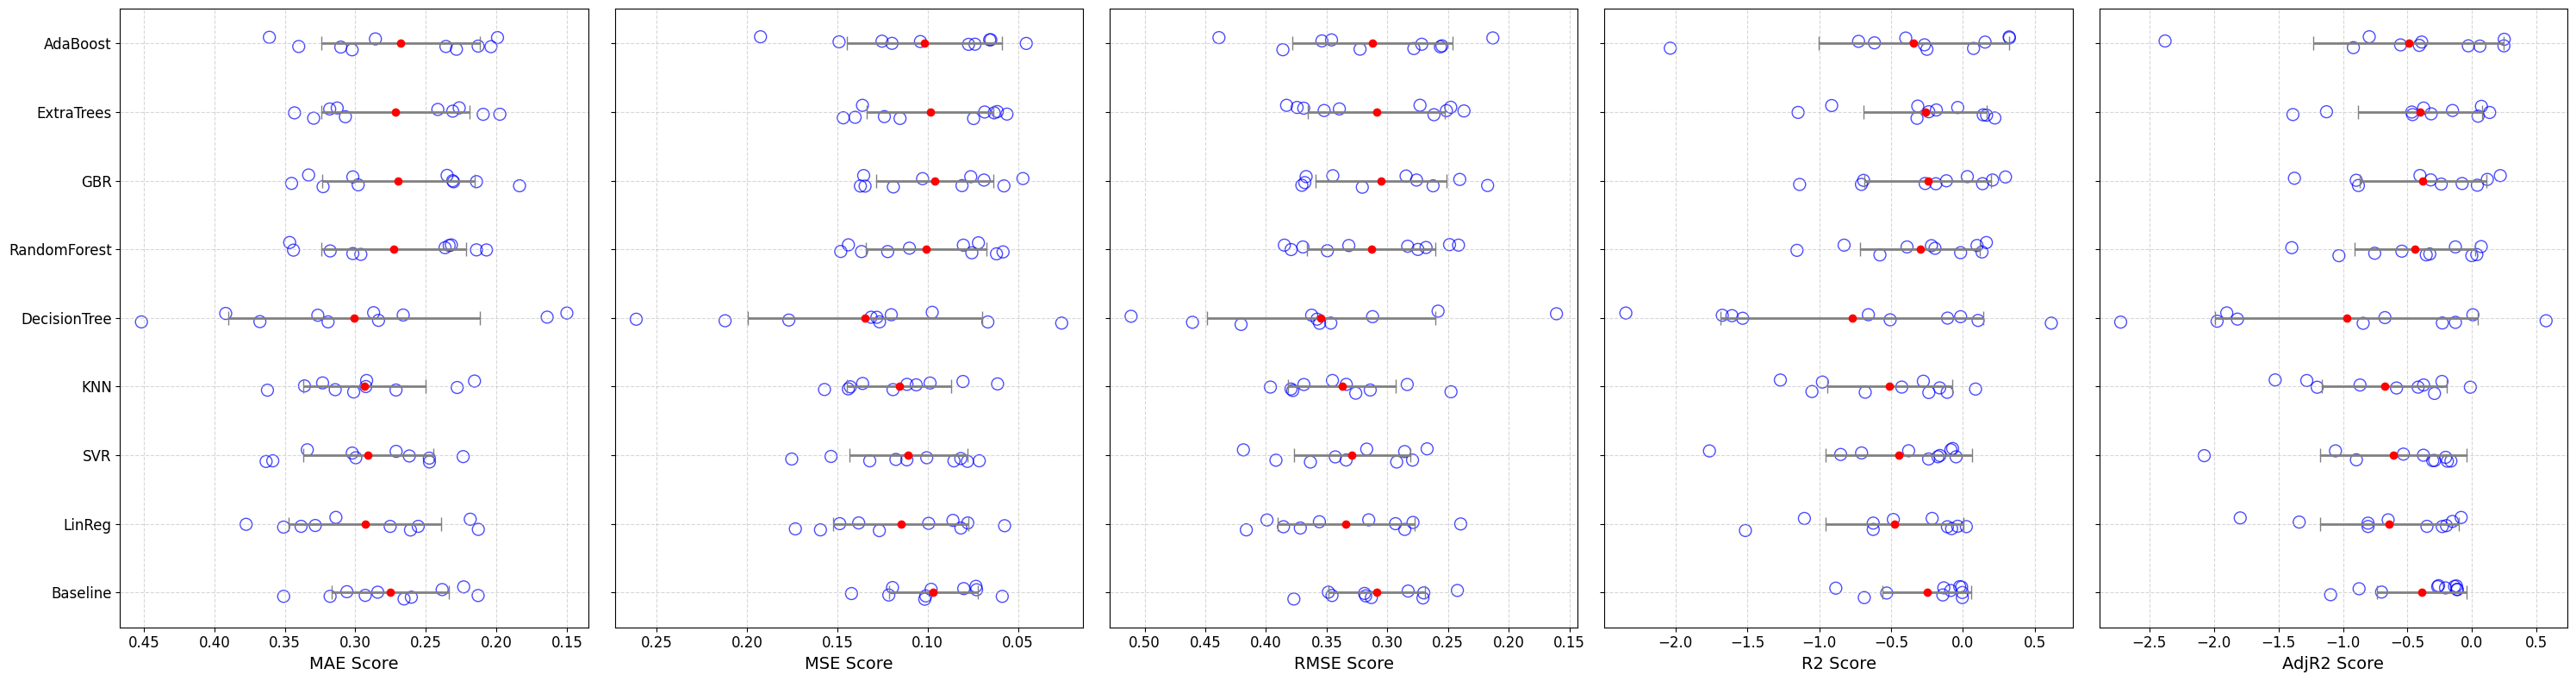

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

# ----------------------------------------------------------------------------
# 0) Helper for Adjusted R²
# ----------------------------------------------------------------------------
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# ----------------------------------------------------------------------------
# 1) Base models + param distributions for tuning
# ----------------------------------------------------------------------------
base_models = [
    ("Baseline",     DummyRegressor(strategy="mean")),
    ("LinReg",       Pipeline([("scaler", StandardScaler()),
                               ("model",  LinearRegression())])),
    ("SVR",          Pipeline([("scaler", StandardScaler()),
                               ("model",  SVR())])),
    ("KNN",          Pipeline([("scaler", StandardScaler()),
                               ("model",  KNeighborsRegressor())])),
    ("DecisionTree", DecisionTreeRegressor(random_state=42)),
    ("RandomForest", RandomForestRegressor(random_state=42)),
    ("GBR",          GradientBoostingRegressor(random_state=42)),
    ("ExtraTrees",   ExtraTreesRegressor(random_state=42)),
    ("AdaBoost",     AdaBoostRegressor(random_state=42))
]

param_dist = {
    "SVR": {
        "model__C":       [0.1, 1, 10],
        "model__gamma":   ["scale","auto"]
    },
    "KNN": {
        "model__n_neighbors": [3,5,7]
    },
    "DecisionTree": {
        "max_depth":           [None,5,10],
        "min_samples_split":   [2,5]
    },
    "RandomForest": {
        "n_estimators": [100,300],
        "max_depth":    [None,10,20]
    },
    "GBR": {
        "n_estimators":    [100,200],
        "learning_rate":   [0.01,0.1],
        "max_depth":       [3,5]
    },
    "ExtraTrees": {
        "n_estimators":  [100,300],
        "max_depth":     [None,10]
    },
    "AdaBoost": {
        "n_estimators":   [50,100],
        "learning_rate":  [0.01,0.1,1.0]
    }
}

# ----------------------------------------------------------------------------
# 2) Tune via RandomizedSearchCV
# ----------------------------------------------------------------------------
tuned_models = []
for name, est in base_models:
    if name in param_dist:
        print(f"Tuning {name}...")
        rs = RandomizedSearchCV(
            est,
            param_dist[name],
            n_iter=15,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=42
        )
        rs.fit(X_train, y_train)
        print(" ", name, "best params:", rs.best_params_)
        tuned_models.append((name, rs.best_estimator_))
    else:
        tuned_models.append((name, est))

# ----------------------------------------------------------------------------
# 3) Cross-validate to get per-fold scores
# ----------------------------------------------------------------------------
scoring = {
    "MAE": make_scorer(mean_absolute_error,   greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,    greater_is_better=False),
    "R2":  make_scorer(r2_score,              greater_is_better=True)
}

cv_folds = 10
n_samples, n_features = X_train.shape

# collect arrays of fold-scores for each metric/model
panel = {m: {} for m in ["MAE","MSE","RMSE","R2","AdjR2"]}

for name, est in tuned_models:
    print("CV on", name)
    res = cross_validate(
        est,
        X_train,
        y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    mae_scores  = -res["test_MAE"]
    mse_scores  = -res["test_MSE"]
    rmse_scores = np.sqrt(mse_scores)
    r2_scores   =  res["test_R2"]
    adjr2_scores = adjusted_r2(r2_scores, n_samples, n_features)

    panel["MAE"][name]   = mae_scores
    panel["MSE"][name]   = mse_scores
    panel["RMSE"][name]  = rmse_scores
    panel["R2"][name]    = r2_scores
    panel["AdjR2"][name] = adjr2_scores

# ----------------------------------------------------------------------------
# 4) Plot jitter+errorbar display (not boxplots)
# ----------------------------------------------------------------------------
metrics = ["MAE","MSE","RMSE","R2","AdjR2"]
fig, axes = plt.subplots(1, len(metrics), figsize=(30,8), sharey=True)

for ax, metric in zip(axes, metrics):
    for i, (name, _) in enumerate(tuned_models):
        scores = panel[metric][name]
        y = np.full_like(scores, i, dtype=float)
        jitter = np.random.uniform(-0.1, 0.1, size=len(scores))
        ax.scatter(scores, y + jitter,
                   edgecolor="blue", facecolors="none",
                   alpha=0.7, s=100)

    means = [panel[metric][name].mean() for name,_ in tuned_models]
    stds  = [panel[metric][name].std()  for name,_ in tuned_models]

    ax.errorbar(means, range(len(tuned_models)),
                xerr=stds,
                fmt='o', color='red',
                ecolor='gray',
                elinewidth=2,
                capsize=6)

    ax.set_yticks(range(len(tuned_models)))
    ax.set_yticklabels([name for name,_ in tuned_models], fontsize=12)
    ax.set_xlabel(f"{metric} Score", fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    if metric in ["MAE","MSE","RMSE"]:
        ax.invert_xaxis()  # smaller is better

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\cleaned_data_w_class.csv")

X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent", "Species_name"])
y = coffee_data["caffeine_class"]

column_names = X.columns

coffee_data.shape

(450, 146)

In [ ]:
df_reg = coffee_data[coffee_data["caffeine_class"] == 1].copy()
X_reg = df_reg.drop(columns=["caffeine_class", "caffeine_percent", "Species_name"])
y_reg = df_reg["caffeine_percent"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_reg.shape

(94, 144)

Tuning DecisionTree...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  DecisionTree best params: {'min_samples_split': 5, 'max_depth': 5}
Tuning RandomForest...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  RandomForest best params: {'n_estimators': 100, 'max_depth': None}
Tuning GBR...


...

  ExtraTrees best params: {'n_estimators': 100, 'max_depth': None}
Tuning AdaBoost...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=15. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  AdaBoost best params: {'n_estimators': 50, 'learning_rate': 0.01}
Tuning LinReg...
  LinReg best params: {'pca__n_components': 0.95}
Tuning SVR...
  SVR best params: {'pca__n_components': 0.9, 'model__gamma': 'scale', 'model__C': 1}
Tuning KNN...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=15. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  KNN best params: {'pca__n_components': 0.8, 'model__n_neighbors': 3}
CV on Baseline
CV on DecisionTree
CV on RandomForest
CV on GBR
CV on ExtraTrees
CV on AdaBoost
CV on LinReg
CV on SVR
CV on KNN
CV on Stacking


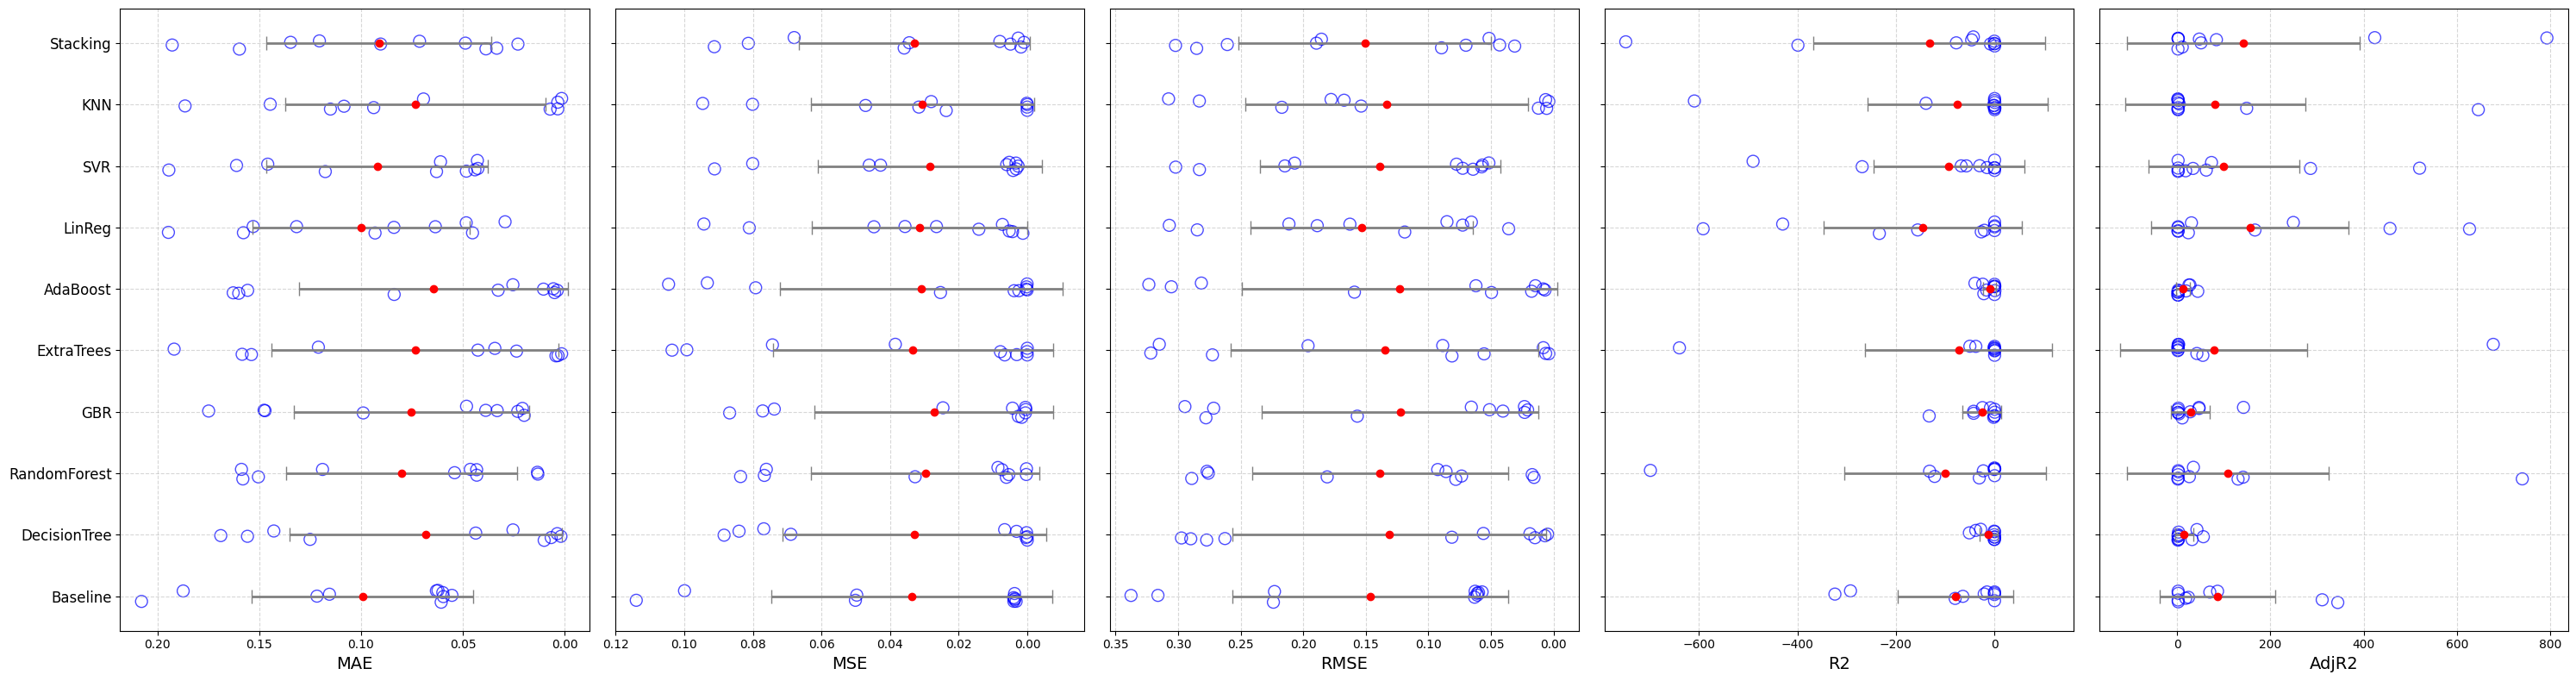

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    StackingRegressor
)

# -----------------------------------------------------------------------------
# 0) Helper for adjusted R²
# -----------------------------------------------------------------------------
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------------------------------------------------------------
# 1) Build model list, injecting PCA only where appropriate
# -----------------------------------------------------------------------------
base_models = [
    # no PCA for baseline or tree‐based learners
    ("Baseline",     DummyRegressor(strategy="mean")),
    ("DecisionTree", DecisionTreeRegressor(random_state=42)),
    ("RandomForest", RandomForestRegressor(random_state=42)),
    ("GBR",          GradientBoostingRegressor(random_state=42)),
    ("ExtraTrees",   ExtraTreesRegressor(random_state=42)),
    ("AdaBoost",     AdaBoostRegressor(random_state=42)),
    # PCA + Scale + Model for linear‐type learners
    ("LinReg", Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.95)),   # keep 95% variance
        ("model",   LinearRegression())
    ])),
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.90)),   # maybe a bit more aggressive
        ("model",   SVR())
    ])),
    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.90)),
        ("model",   KNeighborsRegressor())
    ])),
]

# -----------------------------------------------------------------------------
# 2) Define random‐search parameter grids (only for those that need tuning)
# -----------------------------------------------------------------------------
param_dist = {
    "SVR": {
        "model__C":       [0.1, 1, 10],
        "model__gamma":   ["scale","auto"],
        "pca__n_components": [0.80, 0.90, 0.95]    # tune how many PCs
    },
    "KNN": {
        "model__n_neighbors": [3,5,7,9],
        "pca__n_components":  [0.80, 0.90, 0.95]
    },
    "LinReg": {
        "pca__n_components":  [0.80, 0.90, 0.95]
    },
    "DecisionTree": {
        "max_depth":         [None,5,10,20],
        "min_samples_split": [2,5,10]
    },
    "RandomForest": {
        "n_estimators": [100,300],
        "max_depth":    [None,10,20]
    },
    "GBR": {
        "n_estimators":    [100,200],
        "learning_rate":   [0.01,0.1],
        "max_depth":       [3,5]
    },
    "ExtraTrees": {
        "n_estimators":  [100,300],
        "max_depth":     [None,10]
    },
    "AdaBoost": {
        "n_estimators":   [50,100,200],
        "learning_rate":  [0.01,0.1,1.0]
    }
}

# -----------------------------------------------------------------------------
# 3) RandomizedSearchCV tuning
# -----------------------------------------------------------------------------
tuned = []
for name, est in base_models:
    if name in param_dist:
        print(f"Tuning {name}...")
        rs = RandomizedSearchCV(
            est,
            param_dist[name],
            n_iter=15,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=42
        )
        rs.fit(X_train, y_train)
        print(f"  {name} best params: {rs.best_params_}")
        tuned.append((name, rs.best_estimator_))
    else:
        tuned.append((name, est))

# -----------------------------------------------------------------------------
# 4) Build a Stacking ensemble, using a PCA+LinReg meta‐learner
# -----------------------------------------------------------------------------
stack = StackingRegressor(
    estimators=[(n, m) for n,m in tuned if n not in ("Baseline","LinReg")],
    final_estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.90)),
        ("lr",      LinearRegression())
    ]),
    cv=5,
    n_jobs=-1
)
tuned.append(("Stacking", stack))

# -----------------------------------------------------------------------------
# 5) Cross‐validate all models, collect per‐fold MAE/MSE/RMSE/R²/AdjR²
# -----------------------------------------------------------------------------
from sklearn.metrics import make_scorer

scoring = {
    "MAE": make_scorer(mean_absolute_error,   greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,    greater_is_better=False),
    "R2":  make_scorer(r2_score,              greater_is_better=True)
}

cv_folds = 10
n, p = X_train.shape

panel = {metric: {} for metric in ["MAE","MSE","RMSE","R2","AdjR2"]}

for name, est in tuned:
    print("CV on", name)
    res = cross_validate(
        est, X_train, y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    maes  = -res["test_MAE"]
    mses  = -res["test_MSE"]
    rmses = np.sqrt(mses)
    r2s   =  res["test_R2"]
    adjs  =  adjusted_r2(r2s, n, p)

    panel["MAE"][name]   = maes
    panel["MSE"][name]   = mses
    panel["RMSE"][name]  = rmses
    panel["R2"][name]    = r2s
    panel["AdjR2"][name] = adjs

# -----------------------------------------------------------------------------
# 6) Plot jittered points + red mean±std bars (your original style)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=True)
metrics = ["MAE","MSE","RMSE","R2","AdjR2"]

for ax, metric in zip(axes, metrics):
    for i, (name, _) in enumerate(tuned):
        scores = panel[metric][name]
        y = np.full_like(scores, i, dtype=float)
        ax.scatter(scores, y + np.random.uniform(-0.1,0.1,len(scores)),
                   edgecolor="blue", facecolors="none",
                   alpha=0.7, s=100)
    means = [panel[metric][n].mean() for n,_ in tuned]
    stds  = [panel[metric][n].std()  for n,_ in tuned]
    ax.errorbar(means, range(len(tuned)), xerr=stds,
                fmt='o', color='red', ecolor='gray',
                elinewidth=2, capsize=6)
    ax.set_yticks(range(len(tuned)))
    ax.set_yticklabels([n for n,_ in tuned], fontsize=12)
    ax.set_xlabel(metric, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    if metric in ("MAE","MSE","RMSE"):
        ax.invert_xaxis()

plt.tight_layout()
plt.show()


Tuning DecisionTree...
  DecisionTree best params: {'min_samples_split': 5, 'max_depth': 5}
Tuning RandomForest...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  RandomForest best params: {'n_estimators': 100, 'max_depth': None}
Tuning GBR...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 8 is smaller than n_iter=15. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  GBR best params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01}
Tuning ExtraTrees...


...

  AdaBoost best params: {'n_estimators': 50, 'learning_rate': 0.01}
Tuning LinReg...
  LinReg best params: {'pca__n_components': 0.95}
Tuning SVR...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=15. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  SVR best params: {'pca__n_components': 0.9, 'model__gamma': 'scale', 'model__C': 1}
Tuning KNN...


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=15. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  KNN best params: {'pca__n_components': 0.8, 'model__n_neighbors': 3}
CV on Baseline
CV on DecisionTree
CV on RandomForest
CV on GBR
CV on ExtraTrees
CV on AdaBoost
CV on LinReg
CV on SVR
CV on KNN
CV on Stacking


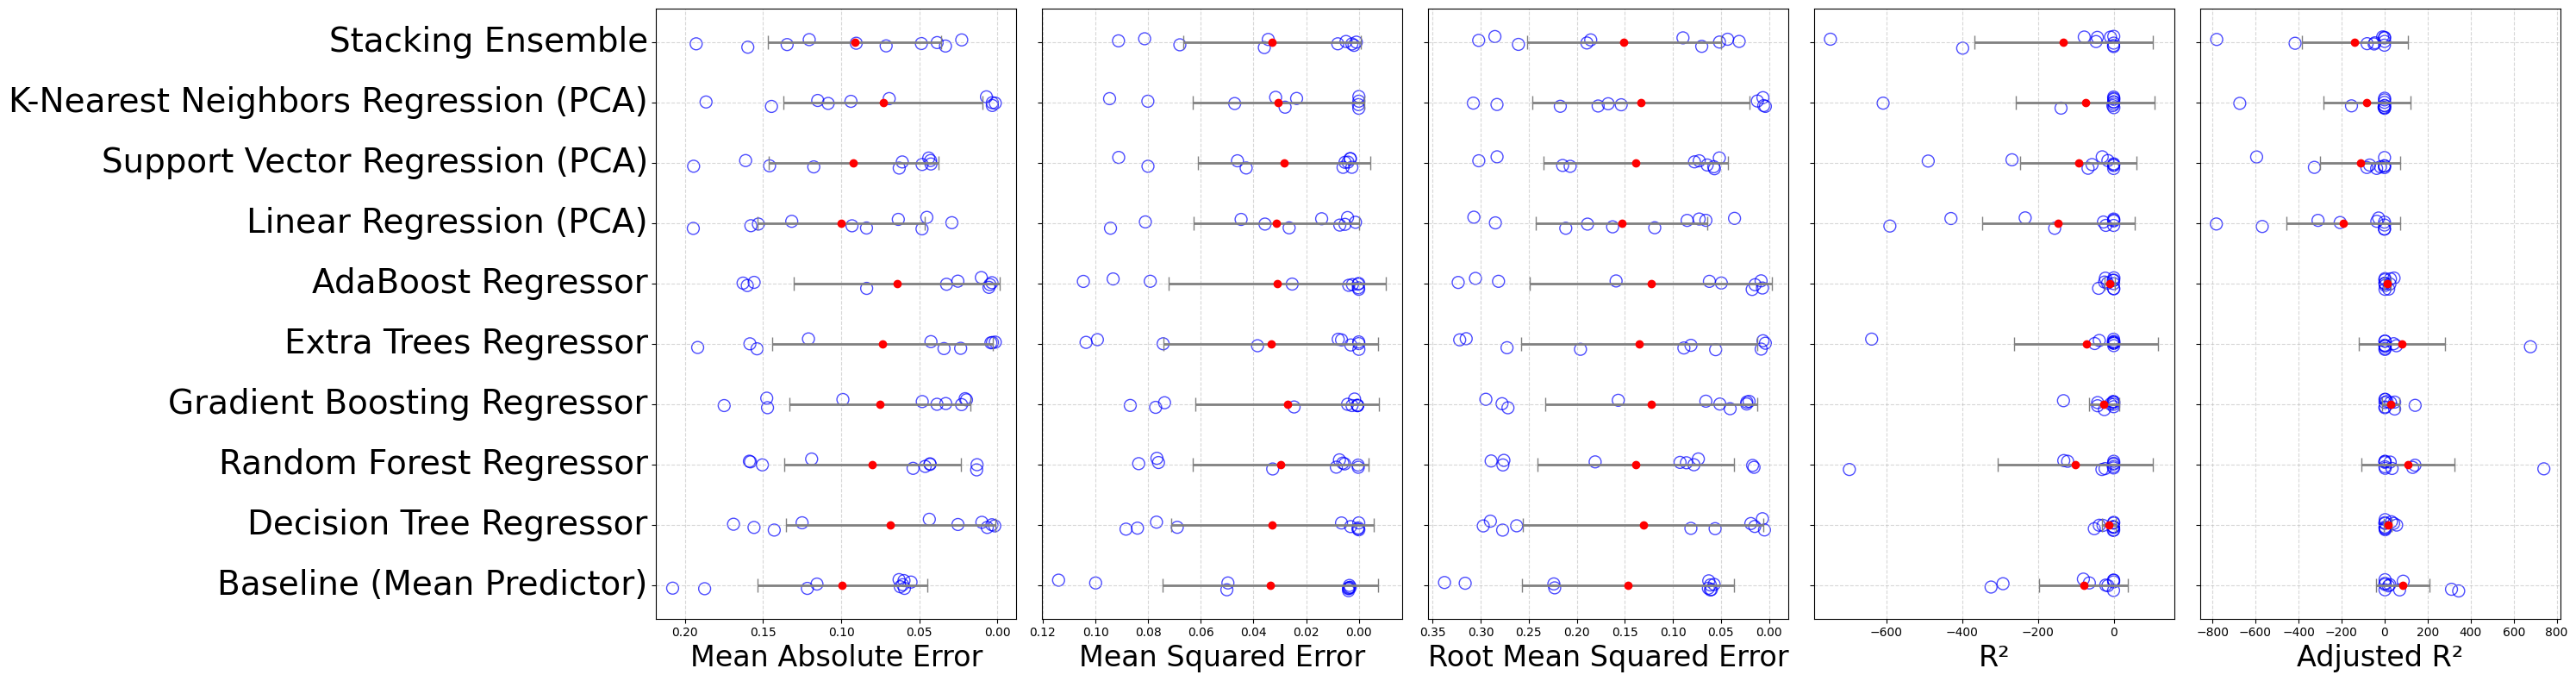

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    StackingRegressor
)

# -----------------------------------------------------------------------------
# 0) Adjusted R² helper
# -----------------------------------------------------------------------------
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------------------------------------------------------------
# 1) Build your base models, injecting PCA only where desired
# -----------------------------------------------------------------------------
base_models = [
    # no PCA for baseline or tree ensembles
    ("Baseline",     DummyRegressor(strategy="mean")),
    ("DecisionTree", DecisionTreeRegressor(random_state=42)),
    ("RandomForest", RandomForestRegressor(random_state=42)),
    ("GBR",          GradientBoostingRegressor(random_state=42)),
    ("ExtraTrees",   ExtraTreesRegressor(random_state=42)),
    ("AdaBoost",     AdaBoostRegressor(random_state=42)),
    # PCA + scale + model for linear‐type learners
    ("LinReg", Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.95)),   # keep 95% variance
        ("model",   LinearRegression())
    ])),
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.90)),
        ("model",   SVR())
    ])),
    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.90)),
        ("model",   KNeighborsRegressor())
    ])),
]

# -----------------------------------------------------------------------------
# 2) Hyperparameter distributions for RandomizedSearch
# -----------------------------------------------------------------------------
param_dist = {
    "DecisionTree": {"max_depth":[None,5,10,20], "min_samples_split":[2,5,10]},
    "RandomForest": {"n_estimators":[100,300], "max_depth":[None,10,20]},
    "GBR":          {"n_estimators":[100,200], "learning_rate":[0.01,0.1], "max_depth":[3,5]},
    "ExtraTrees":   {"n_estimators":[100,300], "max_depth":[None,10]},
    "AdaBoost":     {"n_estimators":[50,100,200], "learning_rate":[0.01,0.1,1.0]},
    "LinReg":       {"pca__n_components":[0.80,0.90,0.95]},
    "SVR":          {"model__C":[0.1,1,10], "model__gamma":["scale","auto"], "pca__n_components":[0.80,0.90,0.95]},
    "KNN":          {"model__n_neighbors":[3,5,7], "pca__n_components":[0.80,0.90,0.95]},
}

# -----------------------------------------------------------------------------
# 3) Tune each model where we have a grid
# -----------------------------------------------------------------------------
tuned_models = []
for name, est in base_models:
    if name in param_dist:
        print(f"Tuning {name}...")
        rs = RandomizedSearchCV(
            est,
            param_dist[name],
            n_iter=15,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=42
        )
        rs.fit(X_train, y_train)
        print(f"  {name} best params: {rs.best_params_}")
        tuned_models.append((name, rs.best_estimator_))
    else:
        tuned_models.append((name, est))

# -----------------------------------------------------------------------------
# 4) Add a Stacking ensemble (with its own PCA in the meta‐learner)
# -----------------------------------------------------------------------------
stack = StackingRegressor(
    estimators=[(n,m) for n,m in tuned_models if n not in ("Baseline","LinReg")],
    final_estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("pca",     PCA(n_components=0.90)),
        ("lr",      LinearRegression())
    ]),
    cv=5,
    n_jobs=-1
)
tuned_models.append(("Stacking", stack))

# -----------------------------------------------------------------------------
# 5) Fit each tuned model on the full training data to record its "p_eff"
# -----------------------------------------------------------------------------
p_eff = {}
for name, est in tuned_models:
    est.fit(X_train, y_train)
    if hasattr(est, "named_steps") and "pca" in est.named_steps:
        # pipeline with PCA
        p_eff[name] = est.named_steps["pca"].n_components_
    elif isinstance(est, StackingRegressor):
        # meta‐learner has a PCA step
        meta = est.final_estimator_
        p_eff[name] = meta.named_steps["pca"].n_components_
    else:
        # full‐feature model
        p_eff[name] = X_train.shape[1]

# -----------------------------------------------------------------------------
# 6) 10‐fold CV to collect per‐fold MAE/MSE/RMSE/R2
# -----------------------------------------------------------------------------
from sklearn.metrics import make_scorer

scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds     = 10
n_samples, _ = X_train.shape

# panel to hold arrays
panel = {metric: {} for metric in ["MAE","MSE","RMSE","R2","AdjR2"]}

for name, est in tuned_models:
    print("CV on", name)
    res = cross_validate(
        est, X_train, y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    # flip signs for the negated errors
    maes  = -res["test_MAE"]
    mses  = -res["test_MSE"]
    rmses = np.sqrt(mses)
    r2s   =  res["test_R2"]
    # now compute adjusted R2 using this model's effective p
    adjs  = adjusted_r2(r2s, n_samples, p_eff[name])

    panel["MAE"][name]    = maes
    panel["MSE"][name]    = mses
    panel["RMSE"][name]   = rmses
    panel["R2"][name]     = r2s
    panel["AdjR2"][name]  = adjs

display_names = {
    "Baseline":     "Baseline (Mean Predictor)",
    "DecisionTree": "Decision Tree Regressor",
    "RandomForest": "Random Forest Regressor",
    "GBR":          "Gradient Boosting Regressor",
    "ExtraTrees":   "Extra Trees Regressor",
    "AdaBoost":     "AdaBoost Regressor",
    "LinReg":       "Linear Regression (PCA)",
    "SVR":          "Support Vector Regression (PCA)",
    "KNN":          "K-Nearest Neighbors Regression (PCA)",
    "Stacking":     "Stacking Ensemble"
}

# -----------------------------------------------------------------------------
# 7) Plot the multi‐panel jitter + mean±std bars
# -----------------------------------------------------------------------------
metrics = ["MAE","MSE","RMSE","R2","AdjR2"]
fig, axes = plt.subplots(1, len(metrics), figsize=(30, 8), sharey=True)
xlabel_map = {
    "MAE":   "Mean Absolute Error",
    "MSE":   "Mean Squared Error",
    "RMSE":  "Root Mean Squared Error",
    "R2":    "R\u00b2",
    "AdjR2": "Adjusted R\u00b2"
}
for ax, metric in zip(axes, metrics):
    for i, (name, _) in enumerate(tuned_models):
        scores = panel[metric][name]
        ax.scatter(
            scores,
            np.full_like(scores, i, dtype=float) + np.random.uniform(-0.1,0.1,len(scores)),
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=100
        )
    means = [panel[metric][n].mean() for n,_ in tuned_models]
    stds  = [panel[metric][n].std()  for n,_ in tuned_models]
    ax.errorbar(
        means,
        range(len(tuned_models)),
        xerr=stds,
        fmt='o',
        color='red',
        ecolor='gray',
        elinewidth=2,
        capsize=6
    )
    # ax.set_yticks(range(len(metric_results_df['Model'])))
    # ax.set_yticklabels(metric_results_df['Model'], fontsize=30)
    # ax.set_xlabel(f'{metric.upper()} Score', fontsize=24)
    # ax.tick_params(axis='x', labelsize=20)
    # ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_yticks(range(len(tuned_models)))
    #ax.set_yticklabels([n for n,_ in tuned_models], fontsize=30)
    ax.set_yticklabels(
        [display_names[n] for n,_ in tuned_models],
        fontsize=28,
        va="center"
        )
    #ax.set_xlabel(f"{metric}", fontsize=24)
    ax.set_xlabel(xlabel_map[metric], fontsize=24)
    ax.grid(True, linestyle='--', alpha=0.5)
    if metric in ("MAE","MSE","RMSE"):
        ax.invert_xaxis()  # smaller is better

plt.tight_layout()
plt.show()
